# 🎵 Notebook 8: Sequential Recommendation
## SASRec-Style Transformer — Personalized Next-Song Prediction

---

> **Notebook 8 of 9** | Prerequisites: Notebooks 1–7 complete.  
> Required files: `encoder_best.pt`, `song_embeddings_trained.npy`, `subset_50.csv`, `id_resnet.tsv`

---

### What This Notebook Builds

```
Problem: Even with great song embeddings from NB7, we still need to
         model the USER — their preferences, their listening history,
         the ORDER in which they listened.

Solution: A Sequential Recommendation Transformer (SASRec-style).

Input:  User listening history = sequence of song IDs
        [song_3, song_17, song_42, song_8, ...]

Output: Predicted next song embedding → find nearest neighbor in catalog

Pipeline:
  User history [s1, s2, ..., sT]
       ↓  look up pretrained embeddings
  Sequence of embeddings [(128,), (128,), ..., (128,)]
       ↓  positional encoding
  Position-aware sequence
       ↓  Causal (masked) Self-Attention
  Contextual sequence representation
       ↓  take last position output
  User state embedding (128,)
       ↓  dot product with all song embeddings
  Ranking scores over catalog
       ↓  Top-N
  Recommended songs
```

### Image Modality Note

This project uses **pre-computed ResNet-4096 vectors** from `id_resnet.tsv`  
(Music4AllOnion Zenodo release) instead of raw album cover images.  
The `VisualProjector` MLP (from NB5/NB6) projects these 4096-dim vectors  
into the shared 128-dim embedding space. No image patches, no ViT patches — just a flat vector lookup from the TSV.

### Why Sequential Modeling Matters

A user who just listened to three aggressive metal songs is in a very different  
state than a user who has the same songs in their **all-time** history but just  
finished a jazz session. **Order matters.** Sequential models capture this.

| Approach | Captures Order | Handles Cold Start | Scalable |
|----------|---------------|-------------------|----------|
| Collaborative Filtering | ❌ | ❌ | ✅ |
| Content-Based (our NB7 embeddings) | ❌ | ✅ | ✅ |
| SASRec (this notebook) | ✅ | ✅ (with NB7 embeddings) | ✅ |

---
## 📐 Mathematical Background

### 8.1 — Sequential Recommendation as Next-Item Prediction

Given user $u$ with interaction history $\mathcal{S}_u = [s_1^u, s_2^u, \ldots, s_T^u]$,  
we want to predict $s_{T+1}^u$.

We frame this as a **ranking problem**: score all catalog songs and return the top-N.

$$\hat{s}_{T+1} = \arg\max_{s \in \mathcal{I}} \text{score}(f(\mathcal{S}_u),\, e_s)$$

Where:
- $f(\mathcal{S}_u)$ = sequential transformer output = **user state embedding** $(128,)$
- $e_s$ = pretrained song embedding from NB7 $(128,)$
- $\text{score}(u, s) = u^\top s$ (dot product, equivalent to cosine if both L2-normalized)

### 8.2 — Causal (Autoregressive) Masking

At position $t$, the model may only attend to positions $\leq t$.  
This is enforced by an **upper-triangular mask**:

$$M_{ij} = \begin{cases} 0 & \text{if } i \geq j \\ -\infty & \text{if } i < j \end{cases}$$

Applied before softmax:
$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$$

After softmax, $-\infty$ positions become exactly 0 — future positions contribute nothing.

**Why this matters for recommendation:**  
Without causal masking, the model at position $t$ could 'look ahead' at $s_{t+1}$ while  
trying to predict $s_{t+1}$. That is information leakage — the model would learn a trivial  
identity function rather than genuine preference patterns.

### 8.3 — BPR Loss (Bayesian Personalized Ranking)

For each training step, we have:
- Anchor: user state $u_t$ at position $t$  
- Positive: the actual next song $s_{t+1}$ (what the user actually listened to)  
- Negative: a randomly sampled song $s^-$ the user did NOT listen to next

$$\mathcal{L}_{\text{BPR}} = -\frac{1}{|\mathcal{T}|} \sum_{(u_t, s^+, s^-)} \log \sigma\!\left(u_t^\top s^+ - u_t^\top s^-\right)$$

**Intuition:** We want $u_t^\top s^+ > u_t^\top s^-$ — the positive should be ranked higher.  
The sigmoid $\sigma(\cdot)$ gives a smooth probability, and log makes it a log-likelihood.

### 8.4 — Positional Encoding for Sequences

Unlike audio patches (which have a natural frequency/time structure), listening history  
positions just mean 'listened first', 'listened second', etc.  
We use **learnable** positional embeddings here (unlike sinusoidal in NB5) because  
listening order has semantic meaning — position 1 vs position 10 in a session mean very different things.

$$\text{input}_t = e_{s_t} + p_t$$

Where $p_t \in \mathbb{R}^{128}$ is a **learned** position embedding for slot $t$.

---
## 🔧 Cell 8.1 — Imports and Configuration

We import everything needed and define all hyperparameters in one place.  
All paths must be consistent with the directory structure from Notebook 1.

**Key design decision — MAX_SEQ_LEN = 20:**  
With only 50 songs, simulated user histories are short. Setting MAX_SEQ_LEN=20  
means the causal mask is (20×20) — tiny. Memory cost: negligible.

**Why EMBED_DIM must match NB7:**  
We are loading `encoder_best.pt` weights. Every dimension must be identical  
to what was defined in NB5/NB6/NB7, or the `load_state_dict` call will crash.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 8.1 — IMPORTS AND CONFIGURATION
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import json
import random
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ───────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Paths — must match NB1 directory structure ────────────────
BASE_DIR      = Path('../')
PROC_AUDIO    = BASE_DIR / 'data' / 'processed' / 'mel_spectrograms'
PROC_LYRICS   = BASE_DIR / 'data' / 'processed' / 'lyric_tokens'
RESNET_TSV    = BASE_DIR / 'data' / 'raw' / 'id_resnet.tsv'   # pre-computed 4096-dim ResNet vectors
MODELS_DIR    = BASE_DIR / 'models'
FIGURES_DIR   = BASE_DIR / 'figures' / 'sequential'
SUBSET_CSV    = BASE_DIR / 'subsets' / 'subset_50.csv'
VOCAB_PATH    = BASE_DIR / 'data' / 'processed' / 'vocabulary.json'
EMBED_PATH    = MODELS_DIR / 'song_embeddings.npy'

RESNET_CACHE = BASE_DIR / "data" / "processed" / "resnet_cache.npy"
RESNET_IDS   = BASE_DIR / "data" / "processed" / "resnet_ids.json"


FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Encoder hyperparameters — MUST MATCH NB5/NB6/NB7 ─────────
EMBED_DIM        = 128
NUM_HEADS        = 2
NUM_LAYERS       = 2
FFN_DIM          = 256
DROPOUT          = 0.1
AUDIO_PATCH_DIM  = 256    # from NB2: (16×16) mel patch
AUDIO_N_PATCHES  = 64     # from NB2
RESNET_DIM       = 4096   # from id_resnet.tsv — ResNet feature size
LYRICS_MAX_LEN   = 256    # from NB3

# ── Sequential recommender hyperparameters ────────────────────
MAX_SEQ_LEN  = 20    # max user history length (positions)
# Why 20? With 50 songs, simulated histories are 5–20 items.
# Causal mask is (20,20)=400 values — absolutely trivial memory.

SEQ_HEADS    = 2     # attention heads in sequential transformer
SEQ_LAYERS   = 2     # encoder layers in sequential transformer
SEQ_FFN_DIM  = 256   # feedforward size
SEQ_DROPOUT  = 0.1

# ── Training hyperparameters ──────────────────────────────────
BATCH_SIZE    = 64     # safe for 8GB GPU
N_EPOCHS      = 40  #100
LR            = 5e-4
WEIGHT_DECAY  = 1e-5
WARMUP_EPOCHS = 10
GRAD_CLIP     = 1.0
TOP_K         = [1, 5, 10]   # evaluation cutoffs
PATIENCE=5
# ── Load vocabulary ───────────────────────────────────────────
if VOCAB_PATH.exists():
    with open(VOCAB_PATH) as f:
        vocab_data = json.load(f)
    LYRICS_VOCAB = vocab_data['vocab_size']
else:
    LYRICS_VOCAB = 5000
    print('⚠️  vocabulary.json not found — using LYRICS_VOCAB=5000')

print(f'\nConfig summary:')
print(f'  Encoder   : embed_dim={EMBED_DIM}, heads={NUM_HEADS}, layers={NUM_LAYERS}')
print(f'  Seq model : max_seq={MAX_SEQ_LEN}, heads={SEQ_HEADS}, layers={SEQ_LAYERS}')
print(f'  ResNet dim: {RESNET_DIM}  (from id_resnet.tsv)')
print(f'  Vocab size: {LYRICS_VOCAB}')
print(f'  Training  : batch={BATCH_SIZE}, epochs={N_EPOCHS}, lr={LR}')

Device: cuda
  GPU : NVIDIA GeForce RTX 4070 SUPER
  VRAM: 12.9 GB

Config summary:
  Encoder   : embed_dim=128, heads=2, layers=2
  Seq model : max_seq=20, heads=2, layers=2
  ResNet dim: 4096  (from id_resnet.tsv)
  Vocab size: 15109
  Training  : batch=64, epochs=40, lr=0.0005


**Expected output:**
```
Device: cuda
  GPU : NVIDIA GeForce RTX ...
  VRAM: 8.0 GB

Config summary:
  Encoder   : embed_dim=128, heads=2, layers=2
  Seq model : max_seq=20, heads=2, layers=2
  ResNet dim: 4096  (from id_resnet.tsv)
  Vocab size: <your vocab>
  Training  : batch=8, epochs=100, lr=0.001
```

**Debugging note:** If `vocabulary.json` is missing, LYRICS_VOCAB defaults to 5000.  
This is fine — the embedding table will just be slightly oversized.

---
## 🔧 Cell 8.2 — Rebuild Full MultimodalSongEncoder from NB5/NB6/NB7

We must **completely redefine** every model class here.  
Notebooks are independent execution environments — we cannot import from NB7.

**Image modality architecture:**  
Instead of a Vision Transformer that takes `(B, 196, 768)` image patches,  
we use `VisualProjector`: a 2-layer MLP that takes `(B, 4096)` ResNet vectors.  
The ResNet backbone already did spatial aggregation — there is no patch sequence  
to attend over. One flat vector → MLP bottleneck → 128-dim image embedding.

```
id_resnet.tsv row:  '0000001'  0.23  -0.11  ...  (4096 values)
                        ↓
                  (B, 4096)  raw ResNet vector
                        ↓   VisualProjector
                  Linear(4096→512) → GELU → Dropout → Linear(512→128)
                        ↓
                  (B, 128)  image embedding  ← same space as audio & lyrics
```

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 8.2 — FULL MULTIMODAL ENCODER (copy from NB6/NB7)
# ─────────────────────────────────────────────────────────────
# We redefine every class so this notebook is self-contained.
# Architecture is IDENTICAL to NB7 — required for load_state_dict.
# ─────────────────────────────────────────────────────────────
# CELL 7.2 — PASTE MODEL CLASSES (NATIVELY MATCHES NB6)
# ─────────────────────────────────────────────────────────────
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e4)  # finite large neg: avoids nan in softmax + safe AMP backward
        attn = F.softmax(scores, dim=-1)
        # nan_to_num removed: -1e4 mask ensures softmax stays finite, no nan produced
        attn = self.dropout(attn)
        return torch.matmul(attn, V), attn

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.W_Q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_O = nn.Linear(embed_dim, embed_dim, bias=False)
        self.attn = ScaledDotProductAttention(dropout)
    def split_heads(self, x):
        B, T, _ = x.shape
        return x.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    def merge_heads(self, x):
        B, h, T, d = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, h * d)
    def forward(self, query, key, value, mask=None):
        Q = self.split_heads(self.W_Q(query))
        K = self.split_heads(self.W_K(key))
        V = self.split_heads(self.W_V(value))
        ctx, aw = self.attn(Q, K, V, mask=mask)
        return self.W_O(self.merge_heads(ctx)), aw

class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_seq_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_seq_len, embed_dim)
        pos = torch.arange(0, max_seq_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class FeedForwardNetwork(nn.Module):
    def __init__(self, embed_dim, ffn_dim, dropout=0.1):
        super().__init__()
        self.l1 = nn.Linear(embed_dim, ffn_dim)
        self.l2 = nn.Linear(ffn_dim, embed_dim)
        self.drop = nn.Dropout(p=dropout)
    def forward(self, x):
        return self.l2(self.drop(F.gelu(self.l1(x))))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.attn  = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.ffn   = FeedForwardNetwork(embed_dim, ffn_dim, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.drop  = nn.Dropout(p=dropout)
    def forward(self, x, mask=None):
        a, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x), mask)
        x = x + self.drop(a)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, num_layers, ffn_dim, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [EncoderBlock(embed_dim, num_heads, ffn_dim, dropout) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x, mask=None):
        for l in self.layers: x = l(x, mask)
        return self.norm(x)

class AudioTransformer(nn.Module):
    def __init__(self, patch_dim, embed_dim, num_heads, num_layers, ffn_dim, n_patches, dropout=0.1):
        super().__init__()
        self.proj    = nn.Linear(patch_dim, embed_dim)
        self.pos_enc = SinusoidalPositionalEncoding(embed_dim, n_patches + 1, dropout)
        self.enc     = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm    = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return self.norm(self.enc(self.pos_enc(self.proj(x))).mean(dim=1))

class LyricsTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ffn_dim, max_len, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc = SinusoidalPositionalEncoding(embed_dim, max_len + 1, dropout)
        self.enc     = TransformerEncoder(embed_dim, num_heads, num_layers, ffn_dim, dropout)
        self.norm    = nn.LayerNorm(embed_dim)
    def forward(self, ids, mask):
        x = self.pos_enc(self.embed(ids))
        x = self.enc(x, mask.unsqueeze(1).unsqueeze(2))
        mf = mask.unsqueeze(-1).float()
        return self.norm((x * mf).sum(1) / mf.sum(1).clamp(min=1))

class VisualProjector(nn.Module):
    def __init__(self, resnet_dim, embed_dim, dropout=0.1):
        super().__init__()
        self.projector = nn.Sequential(
            nn.Linear(resnet_dim, 512),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(512, embed_dim)
        )
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        return self.norm(self.projector(x))

class CrossModalAttention(nn.Module):
    def __init__(self, embed_dim: int):
        super().__init__()
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)
        self.scale = math.sqrt(embed_dim)
        self.norm  = nn.LayerNorm(embed_dim)
        self.last_alpha = None
    def forward(self, e_q: torch.Tensor, e_kv: torch.Tensor) -> torch.Tensor:
        q_proj = self.W_q(e_q)
        k_proj = self.W_k(e_kv)
        v_proj = self.W_v(e_kv)
        score = (q_proj * k_proj).sum(dim=-1, keepdim=True) / self.scale
        alpha = torch.sigmoid(score)
        self.last_alpha = alpha.detach()
        enriched = e_q + alpha * v_proj
        return self.norm(enriched)

class GatedFusion(nn.Module):
    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.gate_net = nn.Sequential(
            nn.Linear(3 * embed_dim, 3 * embed_dim, bias=True),
            nn.Sigmoid()
        )
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.drop = nn.Dropout(p=dropout)
        self.last_gates = None
    def forward(self, A: torch.Tensor, L: torch.Tensor, I: torch.Tensor) -> torch.Tensor:
        concat = torch.cat([A, L, I], dim=-1)
        gates = self.gate_net(concat)
        g_a, g_l, g_i = gates.chunk(3, dim=-1)
        self.last_gates = torch.stack([g_a, g_l, g_i], dim=1).detach()
        fused = g_a * A + g_l * L + g_i * I
        output = self.norm(self.proj(self.drop(fused)))
        return output

class MultimodalFusionModule(nn.Module):
    def __init__(self, embed_dim: int, dropout: float = 0.1):
        super().__init__()
        self.ca_A_L = CrossModalAttention(embed_dim)
        self.ca_A_I = CrossModalAttention(embed_dim)
        self.ca_L_A = CrossModalAttention(embed_dim)
        self.ca_L_I = CrossModalAttention(embed_dim)
        self.ca_I_A = CrossModalAttention(embed_dim)
        self.ca_I_L = CrossModalAttention(embed_dim)
        self.blend_A = nn.Linear(2 * embed_dim, embed_dim)
        self.blend_L = nn.Linear(2 * embed_dim, embed_dim)
        self.blend_I = nn.Linear(2 * embed_dim, embed_dim)
        self.norm_A = nn.LayerNorm(embed_dim)
        self.norm_L = nn.LayerNorm(embed_dim)
        self.norm_I = nn.LayerNorm(embed_dim)
        self.gated_fusion = GatedFusion(embed_dim, dropout)
    def forward(self, A: torch.Tensor, L: torch.Tensor, I: torch.Tensor):
        A_from_L = self.ca_A_L(A, L)
        A_from_I = self.ca_A_I(A, I)
        A_prime  = self.norm_A(self.blend_A(torch.cat([A_from_L, A_from_I], dim=-1)))
        L_from_A = self.ca_L_A(L, A)
        L_from_I = self.ca_L_I(L, I)
        L_prime  = self.norm_L(self.blend_L(torch.cat([L_from_A, L_from_I], dim=-1)))
        I_from_A = self.ca_I_A(I, A)
        I_from_L = self.ca_I_L(I, L)
        I_prime  = self.norm_I(self.blend_I(torch.cat([I_from_A, I_from_L], dim=-1)))
        F = self.gated_fusion(A_prime, L_prime, I_prime)
        return F, (A_prime, L_prime, I_prime)

class MultimodalSongEncoder(nn.Module):
    def __init__(self, d=128, h=2, nl=2, df=256, drop=0.1,
                 apd=256, an=64, V=5000, L=256, resnet_dim=4096):
        super().__init__()
        # Explicit naming to perfectly match Notebook 6 saved states
        self.audio_enc  = AudioTransformer(apd, d, h, nl, df, an, drop)
        self.lyrics_enc = LyricsTransformer(V, d, h, nl, df, L, drop)
        self.vision_enc = VisualProjector(resnet_dim, d, drop)
        self.fusion     = MultimodalFusionModule(d, drop)

    def forward(self, ap, ids, mask, resnet_vec):
        A = self.audio_enc(ap)
        L = self.lyrics_enc(ids, mask)
        I = self.vision_enc(resnet_vec)
        F, _ = self.fusion(A, L, I)
        return F

    def encode_all(self, ap, ids, mask, resnet_vec):
        A = self.audio_enc(ap)
        L = self.lyrics_enc(ids, mask)
        I = self.vision_enc(resnet_vec)
        F, (A_p, L_p, I_p) = self.fusion(A, L, I)
        return {'audio': A, 'lyrics': L, 'image': I, 'unified': F}

# ── Instantiate and load trained weights ──────────────────────
# ── Instantiate and load trained weights ──────────────────────
# Updated to match the exact argument names defined in your custom class above
song_encoder = MultimodalSongEncoder(
    d=EMBED_DIM, 
    h=NUM_HEADS, 
    nl=NUM_LAYERS, 
    df=FFN_DIM, 
    drop=DROPOUT,
    apd=AUDIO_PATCH_DIM, 
    an=AUDIO_N_PATCHES, 
    V=LYRICS_VOCAB, 
    L=LYRICS_MAX_LEN, 
    resnet_dim=RESNET_DIM
).to(device)

encoder_ckpt = MODELS_DIR / 'encoder_best.pt'
if encoder_ckpt.exists():
    song_encoder.load_state_dict(
        torch.load(encoder_ckpt, map_location=device)
    )
    song_encoder.eval()
    print('✅ Loaded encoder_best.pt from NB7 natively into the custom class structure!')
else:
    print('⚠️  encoder_best.pt not found — using random weights')
    print('   Run NB7 first for best results.')

# Freeze the song encoder — we do NOT fine-tune it here.
for param in song_encoder.parameters():
    param.requires_grad = False

n_enc = sum(p.numel() for p in song_encoder.parameters())
print(f'   Encoder params (frozen): {n_enc:,}')

✅ Loaded encoder_best.pt from NB7 natively into the custom class structure!
   Encoder params (frozen): 5,219,840


**Expected output:**
```
✅ Loaded encoder_best.pt from NB7
   Encoder params (frozen): 2,xxx,xxx
```

**Debugging note:**  
If you get a `RuntimeError: Error(s) in loading state_dict` it means EMBED_DIM,  
NUM_HEADS, NUM_LAYERS, LYRICS_VOCAB, or RESNET_DIM here does not match NB7.  
Check those constants carefully — they must be byte-for-byte identical.

---
## 🔧 Cell 8.3 — Load ResNet TSV and Pre-Compute All Song Embeddings

We do two things here:

1. **Load the ResNet TSV** — the file has no header. Column 0 is the song ID  
   (zero-padded string like `'0000001'`), columns 1–4096 are the ResNet features.  
   We **must** use `dtype={0: str}` — without it, pandas parses `'0000001'` as  
   the integer `1`, `str(1)` gives `'1'`, and every lookup returns zeros silently.

2. **Pre-compute all 50 song embeddings** — run each song through the frozen encoder  
   once and cache the result. During sequential model training, we look up these  
   cached embeddings instead of re-running the encoder on every batch.  
   This saves enormous compute time and VRAM.

```
Memory cost of embedding cache:
  50 songs × 128 floats × 4 bytes = 25,600 bytes ≈ 25 KB   ← trivial

Alternative (re-running encoder each batch):
  Each encoder forward: ~100 MB VRAM for audio+lyrics+ResNet inputs
  100 epochs × 6 batches × encoder forward = 600 extra passes — wasted compute
```

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 8.3 — LOAD DATA + BUILD SONG EMBEDDING LOOKUP TABLE
# ─────────────────────────────────────────────────────────────

# ── Load subset metadata ──────────────────────────────────────
assert SUBSET_CSV.exists(), f'subset_50.csv not found at {SUBSET_CSV}'

df_sub = pd.read_csv(SUBSET_CSV, dtype={'id': str})
# dtype={'id': str} — keeps '0000001' as string, not int 1

print(f'Subset: {len(df_sub)} songs')
print(f'Columns: {df_sub.columns.tolist()}')
print(f'ID dtype: {df_sub["id"].dtype}  sample: {df_sub["id"].iloc[0]}')

# Build a clean song list in a fixed order
# Index 0..N-1 will be our internal integer song IDs for the sequence model
song_ids  = df_sub['id'].tolist()           # ['0000001', '0000042', ...]
id_to_idx = {sid: i for i, sid in enumerate(song_ids)}   # str → int
idx_to_id = {i: sid for i, sid in enumerate(song_ids)}   # int → str
N_SONGS   = len(song_ids)

print(f'\nN_SONGS = {N_SONGS}')
print(f'id_to_idx sample: {list(id_to_idx.items())[:3]}')

# ============================================================
# RESNET CACHE
# ============================================================
if RESNET_CACHE.exists() and RESNET_IDS.exists():
    _mat = np.load(str(RESNET_CACHE), mmap_mode='r')   # (N_tsv, 4096), never in RAM
    with open(RESNET_IDS) as f:
        _ids = json.load(f)
    resnet_row = {sid: i for i, sid in enumerate(_ids)}
    resnet_mat = _mat
else:
    raise FileNotFoundError(
        "resnet_cache.npy not found. Run NB1 CELL 3.1 first."
    )
# ── Load ResNet TSV — dtype={0: str} is critical ─────────────
# TSV structure (no header):
#   col 0  : song id  e.g. '0000001'
#   col 1–4096: ResNet features (float)
#
# Without dtype={0: str}: '0000001' parsed as int 1
#                         str(1) = '1' ≠ '0000001' → all misses → all zeros


# ── Helper: load one song's preprocessed data ─────────────────
def load_song_data(sid: str):
    """
    Load all three modalities for one song.
    Falls back to zeros if file is missing — ensures no crash.

    Returns:
        audio:  (AUDIO_N_PATCHES, AUDIO_PATCH_DIM)  numpy float32
        ids:    (LYRICS_MAX_LEN,)                   numpy int64
        mask:   (LYRICS_MAX_LEN,)                   numpy int64
        resnet: (4096,)                             numpy float32
    """
    def _npy(path, shape, dtype=np.float32):
        p = Path(path)
        return np.load(p).astype(dtype) if p.exists() else np.zeros(shape, dtype=dtype)
    
    audio = _npy(PROC_AUDIO / 'mel_all.npy', (N_SONGS, AUDIO_N_PATCHES, AUDIO_PATCH_DIM))[id_to_idx[sid]]
    ids = _npy(PROC_LYRICS / 'token_ids_all.npy', (N_SONGS, LYRICS_MAX_LEN), dtype=np.int64)[id_to_idx[sid]]
    mask = _npy(PROC_LYRICS / 'attn_mask_all.npy', (N_SONGS, LYRICS_MAX_LEN), dtype=np.int64)[id_to_idx[sid]]
    
    row = resnet_row.get(sid)
    resnet = resnet_mat[row].copy() if row is not None else np.zeros(RESNET_DIM, np.float32)

    return audio, ids, mask, resnet

# ── Pre-compute all song embeddings (use cached NB7 output or recompute) ──
recompute = False

if EMBED_PATH and Path(EMBED_PATH).exists():
    song_emb_matrix = np.load(EMBED_PATH).astype(np.float32)  # (N, 128)
    print(f'\n✅ Loaded pre-computed embeddings: {song_emb_matrix.shape}')
    if song_emb_matrix.shape[0] != N_SONGS:
        print(f'⚠️  Shape mismatch: expected ({N_SONGS}, {EMBED_DIM}), got {song_emb_matrix.shape}')
        print('   Recomputing from encoder...')
        recompute = True
else:
    recompute = True

if recompute:
    print('\nRecomputing song embeddings from frozen encoder...')
    song_encoder.eval()
    
    EMBED_SAVE_PATH = MODELS_DIR / 'song_embeddings.npy'
    
    # Use Memmap to handle large writes without blowing up RAM
    song_emb_matrix = np.lib.format.open_memmap(
        EMBED_SAVE_PATH, 
        mode='w+', 
        dtype='float32', 
        shape=(N_SONGS, EMBED_DIM)
    )
    
    with torch.no_grad():
        row = 0
        for i in range(0, N_SONGS, 8):
            batch_sids = song_ids[i:i+8]
            data = [load_song_data(sid) for sid in batch_sids]
            B = len(batch_sids)
            
            audio_b  = torch.tensor(np.stack([d[0] for d in data])).to(device)
            ids_b    = torch.tensor(np.stack([d[1] for d in data])).to(device)
            mask_b   = torch.tensor(np.stack([d[2] for d in data])).to(device)
            resnet_b = torch.tensor(np.stack([d[3] for d in data])).to(device)
            
            emb = song_encoder(audio_b, ids_b, mask_b, resnet_b)
            song_emb_matrix[row:row+B] = emb.cpu().numpy()
            row += B
            
    # Flush memmap changes to disk and load as standard numpy array for the rest of the notebook
    song_emb_matrix.flush()
    song_emb_matrix = np.array(song_emb_matrix) 
    EMBED_PATH = EMBED_SAVE_PATH  # Update path variable
    
    print(f'✅ Saved embeddings → {EMBED_SAVE_PATH}')
    print(f'✅ Recomputed and saved: {song_emb_matrix.shape}')

# ============================================================
# SMART GPU MEMORY GUARD
# ============================================================
embedding_size_mb = song_emb_matrix.nbytes / 1e6

print(f'\nEmbedding table size: {embedding_size_mb:.2f} MB')

if embedding_size_mb < 400:
    SONG_EMB_TENSOR = torch.from_numpy(song_emb_matrix).to(device)
    SONG_EMB_ON_GPU = True
    print('✅ Embeddings moved to GPU')
else:
    SONG_EMB_TENSOR = torch.from_numpy(song_emb_matrix)
    SONG_EMB_ON_GPU = False
    print('⚠️ Embeddings kept on CPU (too large for VRAM)')

print(f'SONG_EMB_TENSOR shape: {SONG_EMB_TENSOR.shape}')


# ── Sanity checks ─────────────────────────────────────────────
assert song_emb_matrix.shape == (N_SONGS, EMBED_DIM), \
    f'Expected ({N_SONGS}, {EMBED_DIM}), got {song_emb_matrix.shape}'
assert not np.any(np.isnan(song_emb_matrix)), 'NaN in song embeddings!'

norms = np.linalg.norm(song_emb_matrix, axis=1)
print(f'Embedding norms: min={norms.min():.3f}  max={norms.max():.3f}  mean={norms.mean():.3f}')
print('✅ Song embedding sanity checks passed.')

Subset: 10000 songs
Columns: ['id', 'spotify_id', 'popularity', 'release', 'danceability', 'energy', 'key', 'mode', 'valence', 'tempo', 'duration_ms', 'artist', 'title', 'album_name', 'genre', 'year', 'decade', 'has_lyrics', 'has_audio', 'has_visual', 'completeness']
ID dtype: str  sample: lUJHN9keOtaNGCYK

N_SONGS = 10000
id_to_idx sample: [('lUJHN9keOtaNGCYK', 0), ('3MEb9LZbB80nQ1a8', 1), ('RbaDhF3EoczkLKJl', 2)]

✅ Loaded pre-computed embeddings: (10000, 128)

Embedding table size: 5.12 MB
✅ Embeddings moved to GPU
SONG_EMB_TENSOR shape: torch.Size([10000, 128])
Embedding norms: min=11.284  max=11.401  mean=11.335
✅ Song embedding sanity checks passed.


**Expected output:**
```
Subset: 50 songs
ID dtype: object  sample: 0000001
N_SONGS = 50

Loading ResNet TSV...
  TSV rows loaded : 109,269
  Sample match: id=0000001 → resnet shape=(4096,)  ✅

✅ Loaded pre-computed embeddings: (50, 128)
Song embedding matrix on device: torch.Size([50, 128])
Embedding norms: min=0.8xx  max=1.2xx  mean=1.0xx
✅ Song embedding sanity checks passed.
```

**Debugging: if Sample match shows ⚠️**  
The ID in your subset CSV doesn't match what's in the TSV first column.  
Run this diagnostic:
```python
tsv_keys = list(resnet_row.keys())[:5]
csv_ids  = df_sub['id'].tolist()[:5]
print('TSV keys:', tsv_keys)    # e.g. ['0000001', '0000002']
print('CSV ids :', csv_ids)     # should match format exactly
```

---
## 🔧 Cell 8.4 — Simulate User Listening Histories

With only 50 songs and no real user interaction logs, we must **simulate** histories.  
This is standard practice in cold-start recommendation research with small datasets.

**Simulation strategy:**
- Each simulated user gets a listening history of 5–15 songs
- History is **genre-biased** — a user prefers 1–2 genres but occasionally explores
- This makes the task meaningful: the model must learn preference patterns, not just random lookup

**Why genre-biased simulation is important:**  
Pure random sequences give no signal — every sequence is equally likely.  
Genre-biased sequences create real patterns: if a user listened to 5 rock songs,  
the 6th is likely rock or a related genre. The sequential model should learn this.

```
Simulated user 0: genre_pref=['rock','metal']  history=[7,23,41,12,7,23,19,...]  target=next_song
Simulated user 1: genre_pref=['jazz','classical']  history=[2,44,8,...]  target=next_song
```

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 8.4 — SIMULATE LISTENING HISTORIES
# ─────────────────────────────────────────────────────────────

# ── Build genre → song index mapping ─────────────────────────
genre_to_indices = defaultdict(list)
for i, row in df_sub.iterrows():
    g = str(row.get('genre', 'unknown')).lower().strip()
    genre_to_indices[g].append(i)

print('Songs per genre:')
for g, idxs in sorted(genre_to_indices.items()):
    print(f'  {g:<15}: {len(idxs)} songs  → indices {idxs}')

all_genres_list = list(genre_to_indices.keys())

# ── Simulate user histories ───────────────────────────────────
N_USERS      = 10_000   # simulate 10,000 users
MIN_SEQ      = 6     # minimum history length (need at least 1 context + 1 target)
MAX_HIST_LEN = 20     # maximum history length to sample
GENRE_BIAS   = 0.75   # probability of picking from preferred genre vs random

rng = np.random.default_rng(42)

simulated_histories = []

for user_idx in range(N_USERS):
    # Each user prefers 1–2 genres
    n_pref = rng.integers(1, 3)   # 1 or 2 preferred genres
    pref_genres = rng.choice(all_genres_list, size=n_pref, replace=False).tolist()
    pref_indices = []
    for g in pref_genres:
        pref_indices.extend(genre_to_indices[g])

    # Build a listening sequence
    seq_len = rng.integers(MIN_SEQ, MAX_HIST_LEN + 1)
    history = []
    for _ in range(seq_len):
        if rng.random() < GENRE_BIAS and len(pref_indices) > 0:
            # Pick from preferred genres (with replacement allowed — re-listening)
            item = int(rng.choice(pref_indices))
        else:
            # Explore: pick any song
            item = int(rng.integers(0, N_SONGS))
        history.append(item)

    simulated_histories.append({
        'user_id':    user_idx,
        'pref_genres': pref_genres,
        'history':    history,         # list of song indices (ints)
    })

print(f'\n✅ Simulated {N_USERS} user histories')
print(f'\nSample histories:')
for u in simulated_histories[:3]:
    print(f"  User {u['user_id']:3d} | pref={u['pref_genres']} | "
          f"len={len(u['history'])} | history={u['history']}")

# ── Statistics ────────────────────────────────────────────────
hist_lens = [len(u['history']) for u in simulated_histories]
print(f'\nHistory length stats:')
print(f'  Min: {min(hist_lens)}  Max: {max(hist_lens)}  Mean: {np.mean(hist_lens):.1f}')

# ── Extract (context, target) training pairs from histories ───
# For each history of length T, we create T-1 training pairs:
#   context = history[0:t]  (up to MAX_SEQ_LEN, left-padded)
#   target  = history[t]    (the actual next song)
#
# This is the standard 'leave-one-out with sliding window' approach.

training_pairs  = []   # (context_sequence, target_idx)
validation_pairs = []  # last item of each user = validation target

for u in simulated_histories:
    hist = u['history']
    if len(hist) < 2:
        continue

    # Validation pair: use last item as target, second-to-last as context end
    val_context = hist[:-1]
    val_target  = hist[-1]
    validation_pairs.append((val_context, val_target))

    # Training pairs: all other (context, next) windows
    for t in range(1, len(hist) - 1):   # exclude last (reserved for val)
        ctx = hist[:t]    # context up to position t-1
        tgt = hist[t]     # actual next song
        training_pairs.append((ctx, tgt))

print(f'\nTraining pairs  : {len(training_pairs):,}')
print(f'Validation pairs: {len(validation_pairs):,}')

# Sample training pair inspection
ctx_ex, tgt_ex = training_pairs[0]
print(f'\nSample training pair:')
print(f'  Context (song indices): {ctx_ex}')
print(f'  Target  (song index)  : {tgt_ex}')
print(f'  Target song id: {idx_to_id[tgt_ex]}')
print(f'  Target genre  : {df_sub.iloc[tgt_ex].get("genre", "?")}')

Songs per genre:
  8-bit,electronic,experimental,punk: 1 songs  → indices [7401]
  a cappella     : 1 songs  → indices [4949]
  a cappella,indie rock,rock: 1 songs  → indices [5263]
  a cappella,pop : 2 songs  → indices [7406, 8452]
  abstract       : 1 songs  → indices [6864]
  abstract hip hop,rap,hip hop: 1 songs  → indices [6073]
  acid jazz,funk,ambient: 1 songs  → indices [1672]
  acid jazz,jazz,electronic: 1 songs  → indices [1914]
  acid jazz,jazz,smooth jazz,soul,funk: 1 songs  → indices [1443]
  acid jazz,lounge: 1 songs  → indices [7677]
  adoracao       : 1 songs  → indices [3250]
  afrobeat       : 2 songs  → indices [321, 458]
  alternative hip hop,punk: 1 songs  → indices [7762]
  alternative metal: 4 songs  → indices [4024, 4676, 4991, 7998]
  alternative metal,alternative rock: 1 songs  → indices [4528]
  alternative metal,alternative rock,metal: 2 songs  → indices [3239, 4458]
  alternative metal,alternative rock,post-grunge,alternative rock,rock,hard rock: 1 songs  →

**Expected output:**
```
Songs per genre:
  classical      : 5 songs  → indices [0, 1, 2, 3, 4]
  country        : 5 songs  → indices [5, 6, 7, 8, 9]
  ...

✅ Simulated 200 user histories

Training pairs  : ~1,200
Validation pairs: 200
```

**Why `T-1` training pairs per history?**  
At each position $t$, the model sees $[s_0, ..., s_{t-1}]$ and must predict $s_t$.  
A history of length 10 gives 9 training pairs — efficient use of limited data.

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 8.4b — TRAIN / VALIDATION / TEST SPLIT FOR SASREC
# ─────────────────────────────────────────────────────────────
# Split the simulated (context, target) pairs into three sets:
#
#   TRAIN  : ~85% of pairs  → used for gradient updates
#   VAL    : ~15% of pairs  → early stopping + hyperparam tuning
#   TEST   : 10,000 pairs   → final reported metrics (run ONCE)
#
# Splitting at the PAIR level (not user level) because:
#   - With simulated users there are no "held-out users"
#   - Pair-level split ensures the model sees diverse contexts
#
# NOTE: validation_pairs from CELL 8.4 was the "last item of
#       each user" — that is now promoted to test_pairs.
#       We explicitly filter training_pairs to prevent data leakage.
# ─────────────────────────────────────────────────────────────

import numpy as np

rng_split = np.random.default_rng(99)   # fixed seed for reproducibility

# 1. Establish the test set first
test_pairs = validation_pairs   # these were never used during training
test_set   = set(tuple(c) + (t,) for c, t in test_pairs)

# 2. Filter the sliding-window pairs to remove ANY overlap with the test set
clean_training_pairs = [
    (c, t) for c, t in training_pairs
    if (tuple(c) + (t,)) not in test_set
]

# 3. Shuffle and split the cleaned training pairs
shuffled = list(clean_training_pairs)
rng_split.shuffle(shuffled)

n_total = len(shuffled)
n_val   = int(n_total * 0.15)
n_train = n_total - n_val

train_pairs = shuffled[:n_train]
val_pairs   = shuffled[n_train:]

print(f"Pair split:")
print(f"  Train : {len(train_pairs):>6,} pairs  ({len(train_pairs)/n_total*100:.0f}% of cleaned sliding-window pairs)")
print(f"  Val   : {len(val_pairs):>6,} pairs  ({len(val_pairs)/n_total*100:.0f}%)")
print(f"  Test  : {len(test_pairs):>6,} pairs  (last-item holdout — run evaluation ONCE at end)")

# 4. Final verification
train_set = set(tuple(c) + (t,) for c, t in train_pairs)
overlap   = train_set & test_set

print(f"\nTrain/test pair overlap: {len(overlap)}  (should be 0)")
assert len(overlap) == 0, "❌ Data leakage detected — train and test share pairs!"
print("✅ No data leakage.")

Pair split:
  Train : 93,693 pairs  (85% of cleaned sliding-window pairs)
  Val   : 16,534 pairs  (15%)
  Test  : 10,000 pairs  (last-item holdout — run evaluation ONCE at end)

Train/test pair overlap: 0  (should be 0)
✅ No data leakage.


---
## 🔧 Cell 8.5 — Sequential Recommendation Dataset

The dataset converts raw (context, target) pairs into fixed-size tensors.

**Padding strategy — left-pad, not right-pad:**  
The sequential transformer reads history left-to-right and outputs at the **last position**.  
If we right-pad, the meaningful history ends somewhere in the middle, and the model  
reads from a padding token and outputs from there — wrong.  
Left-padding ensures the **real history occupies the rightmost positions**, and  
the model's output at position `MAX_SEQ_LEN - 1` captures the most recent context.

```
History: [song3, song17, song42]   MAX_SEQ_LEN=5

Right-pad (wrong):  [song3, song17, song42, PAD, PAD]  → output at pos4 = PAD context
Left-pad  (correct): [PAD,  PAD,  song3, song17, song42] → output at pos4 = full context ✅
```

**Negative sampling:**  
For BPR loss, each training pair needs one negative: a randomly sampled song  
the user did NOT listen to immediately after the context. We sample uniformly  
from all songs except the target — simple but effective with small catalogs.

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 8.5 — SEQUENTIAL RECOMMENDATION DATASET
# ─────────────────────────────────────────────────────────────
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np


class SequentialRecommendationDataset(Dataset):
    """
    Converts (context, target) pairs into fixed-size padded tensors.

    __getitem__ returns:
        seq_emb:    (MAX_SEQ_LEN, EMBED_DIM)  left-padded embedding sequence
        seq_mask:   (MAX_SEQ_LEN,)            1=real position, 0=padding
        pos_target: scalar int                song index of target (positive)
        neg_target: scalar int                song index of negative (randomly sampled)

    Shapes:
        seq_emb   : (20, 128)
        seq_mask  : (20,)     dtype=int64
        pos_target: ()         scalar int64
        neg_target: ()         scalar int64
    """

    def __init__(
        self,
        pairs,
        song_emb_matrix,
        n_songs,
        max_seq_len,
        embed_dim
    ):
        """
        Args:
            pairs          : list of (context: List[int], target: int)
            song_emb_matrix: numpy (N_SONGS, EMBED_DIM)
            n_songs        : catalog size
            max_seq_len    : MAX_SEQ_LEN
            embed_dim      : EMBED_DIM
        """

        self.pairs = pairs
        self.emb_mat = song_emb_matrix.astype(np.float32)
        self.n_songs = n_songs
        self.max_len = max_seq_len
        self.edim = embed_dim

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        context, pos_target = self.pairs[idx]

        # ── Truncate context to MAX_SEQ_LEN (keep most recent) ──
        context = context[-self.max_len:]
        T = len(context)

        # ── Build left-padded sequence tensor ───────────────────
        seq_emb = np.zeros(
            (self.max_len, self.edim),
            dtype=np.float32
        )

        seq_mask = np.zeros(
            self.max_len,
            dtype=np.int64
        )

        # Fill from RIGHT → left padding
        start = self.max_len - T

        for i, song_idx in enumerate(context):
            seq_emb[start + i] = self.emb_mat[song_idx]
            seq_mask[start + i] = 1

        # ────────────────────────────────────────────────────────
        # FIXED NEGATIVE SAMPLING
        # Avoid:
        #   1. Positive target
        #   2. Songs already in listening history
        # ────────────────────────────────────────────────────────
        context_set = set(context)

        neg_target = np.random.randint(
            0,
            self.n_songs
        )

        while (
            neg_target == pos_target
            or neg_target in context_set
        ):
            neg_target = np.random.randint(
                0,
                self.n_songs
            )

        return {
            'seq_emb': torch.from_numpy(seq_emb),
            'seq_mask': torch.from_numpy(seq_mask),
            'pos_target': torch.tensor(
                pos_target,
                dtype=torch.long
            ),
            'neg_target': torch.tensor(
                neg_target,
                dtype=torch.long
            ),
        }


# ── Instantiate datasets and loaders ─────────────────────────
train_dataset = SequentialRecommendationDataset(
    training_pairs,
    song_emb_matrix,
    N_SONGS,
    MAX_SEQ_LEN,
    EMBED_DIM
)

val_dataset = SequentialRecommendationDataset(
    validation_pairs,
    song_emb_matrix,
    N_SONGS,
    MAX_SEQ_LEN,
    EMBED_DIM
)

# FIX FOR WINDOWS HANG
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

print(f'Train dataset : {len(train_dataset):,} pairs')
print(f'Val   dataset : {len(val_dataset):,} pairs')
print(f'Train batches : {len(train_loader)}')


# ── Verify one batch ──────────────────────────────────────────
batch = next(iter(train_loader))

print(f'\nBatch shapes:')
print(f"  seq_emb    : {batch['seq_emb'].shape}")
print(f"  seq_mask   : {batch['seq_mask'].shape}")
print(f"  pos_target : {batch['pos_target'].shape}")
print(f"  neg_target : {batch['neg_target'].shape}")

# Verify left padding
masks = batch['seq_mask']
pad_lengths = MAX_SEQ_LEN - masks.sum(dim=1)

print(
    f'\nPad lengths in first batch: '
    f'{pad_lengths.tolist()}'
)

print(
    '(Pad should be at LEFT — '
    'zeros before first 1 in seq_mask)'
)

# ── Extra debugging for negative sampling ────────────────────
sample_idx = 0
sample_context, sample_pos = train_dataset.pairs[sample_idx]

sample_item = train_dataset[sample_idx]
sample_neg = sample_item['neg_target'].item()

print('\nNegative Sampling Check:')
print('Context length :', len(sample_context))
print('Positive target:', sample_pos)
print('Negative target:', sample_neg)

assert sample_pos != sample_neg, \
    "❌ Positive == Negative"

assert sample_neg not in sample_context, \
    "❌ Negative exists in listening history"

assert batch['seq_emb'].shape == (
    BATCH_SIZE,
    MAX_SEQ_LEN,
    EMBED_DIM
)

assert batch['seq_mask'].shape == (
    BATCH_SIZE,
    MAX_SEQ_LEN
)

assert batch['pos_target'].shape == (
    BATCH_SIZE,
)

print('\n✅ Dataset shape assertions passed.')
print('✅ Negative sampling is correct.')

Train dataset : 110,240 pairs
Val   dataset : 10,000 pairs
Train batches : 1723

Batch shapes:
  seq_emb    : torch.Size([64, 20, 128])
  seq_mask   : torch.Size([64, 20])
  pos_target : torch.Size([64])
  neg_target : torch.Size([64])

Pad lengths in first batch: [8, 14, 15, 18, 15, 16, 19, 13, 7, 3, 19, 15, 2, 13, 16, 14, 13, 13, 13, 16, 9, 19, 15, 6, 10, 13, 11, 17, 18, 4, 8, 19, 3, 4, 6, 14, 15, 14, 13, 15, 5, 12, 15, 10, 12, 5, 10, 17, 11, 2, 12, 16, 16, 19, 12, 12, 12, 7, 11, 10, 12, 18, 9, 4]
(Pad should be at LEFT — zeros before first 1 in seq_mask)

Negative Sampling Check:
Context length : 1
Positive target: 7443
Negative target: 161

✅ Dataset shape assertions passed.
✅ Negative sampling is correct.


**Expected output:**
```
Train dataset : ~1,200 pairs
Val   dataset : 200 pairs

Batch shapes:
  seq_emb    : torch.Size([8, 20, 128])
  seq_mask   : torch.Size([8, 20])
  pos_target : torch.Size([8])
  neg_target : torch.Size([8])

Pad lengths in first batch: [17, 14, 16, 13, 15, 18, 12, 14]
✅ Dataset shape assertions passed.
```

**Tensor shape walkthrough:**
```
seq_emb[0]:    (20, 128)
               ↑ position 0–16: zeros (padding)
               ↑ positions 17–19: actual song embeddings from NB7

seq_mask[0]:   [0,0,0,...,0, 1,1,1]  ← 17 zeros then 3 ones
```

---
## 🔧 Cell 8.6 — SASRec Sequential Transformer

This is the core model of Notebook 8.

**Key differences from the modality encoders (NB5):**

| Feature | Modality Encoder (NB5) | Sequential Recommender (NB8) |
|---------|------------------------|------------------------------|
| Input | Raw patches/tokens | Pre-computed embeddings |
| Attention | Bidirectional (full) | Causal (upper-tri masked) |
| Positional encoding | Sinusoidal (fixed) | Learnable (trained) |
| Output | Single embedding | Per-position outputs |
| Goal | Content understanding | Preference prediction |

**Why learnable positional embeddings here?**  
In the modality encoders, position encodes frequency/time, which has a natural  
mathematical structure that sinusoidal PE captures well.  
In listening history, position means 'how long ago did the user listen to this'.  
Position 20 (most recent) is semantically very different from position 1 (oldest).  
Learnable embeddings let the model discover this structure from data.

**Causal mask shape:**
```
MAX_SEQ_LEN=5, causal mask (upper triangular, 1=attend, 0=block):

position:  0  1  2  3  4
pos 0:   [ 1  0  0  0  0 ]   ← can only see itself
pos 1:   [ 1  1  0  0  0 ]   ← can see pos 0,1
pos 2:   [ 1  1  1  0  0 ]   ← can see pos 0,1,2
pos 3:   [ 1  1  1  1  0 ]   ← can see pos 0,1,2,3
pos 4:   [ 1  1  1  1  1 ]   ← can see all history ← this is the output we use
```

In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 8.6 — SASRec SEQUENTIAL RECOMMENDATION TRANSFORMER
# ─────────────────────────────────────────────────────────────

class CausalMultiHeadAttention(nn.Module):
    """
    Multi-head attention with a causal (autoregressive) mask.

    The causal mask ensures position t can only attend to positions <= t.
    Additionally, padding positions (seq_mask=0) are fully blocked.

    Inputs:
        x        : (B, T, d)   — sequence of embeddings
        pad_mask : (B, T)      — 1=real, 0=padding

    Output:
        (B, T, d)   — self-attended sequence (causal)
    """
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.W_Q  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_K  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_V  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_O  = nn.Linear(embed_dim, embed_dim, bias=False)
        self.drop = nn.Dropout(dropout)
        self.last_attn = None

    def forward(self, x, pad_mask=None):
        B, T, d = x.shape
        h = self.num_heads
        dk = self.head_dim

        # Project: (B,T,d) → (B,h,T,dk)
        def proj_split(W, inp):
            return W(inp).view(B, T, h, dk).transpose(1, 2)

        Q = proj_split(self.W_Q, x)   # (B, h, T, dk)
        K = proj_split(self.W_K, x)
        V = proj_split(self.W_V, x)

        # ── Attention scores: (B, h, T, T) ──────────────────────
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)

        # ── Causal mask: block future positions ──────────────────
        # Lower-triangular matrix of ones: position i can attend to j <= i
        causal = torch.tril(torch.ones(T, T, device=x.device))  # (T, T)
        # Expand to (1, 1, T, T) for broadcasting over batch and heads
        causal = causal.unsqueeze(0).unsqueeze(0)
        scores = scores.masked_fill(causal == 0, float('-inf'))

        # ── Padding mask: block pad positions ────────────────────
        # pad_mask: (B, T)  →  (B, 1, 1, T) — applied to KEY dimension
        # Position i cannot attend to any key position j where pad_mask[j]=0
        if pad_mask is not None:
            pad_exp = pad_mask.unsqueeze(1).unsqueeze(2)   # (B,1,1,T)
            scores  = scores.masked_fill(pad_exp == 0, float('-inf'))

        # ── Softmax + attend ─────────────────────────────────────
        attn   = F.softmax(scores, dim=-1)           # (B, h, T, T)
        attn   = torch.nan_to_num(attn, nan=0.0)    # guard all-masked rows
        self.last_attn = attn.detach()
        attn   = self.drop(attn)
        ctx    = torch.matmul(attn, V)               # (B, h, T, dk)

        # Merge heads: (B, h, T, dk) → (B, T, d)
        ctx = ctx.transpose(1, 2).contiguous().view(B, T, d)
        return self.W_O(ctx)                          # (B, T, d)


class SASRecBlock(nn.Module):
    """
    One SASRec transformer block:
        LayerNorm → CausalMHA → Residual → LayerNorm → FFN → Residual

    Note: SASRec uses PRE-norm (LN before attention), not POST-norm.
    Pre-norm is more stable with small datasets and fewer layers.
    """
    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = CausalMultiHeadAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x, pad_mask=None):
        # Pre-norm residual: x + Attn(LayerNorm(x))
        x = x + self.attn(self.norm1(x), pad_mask)   # (B, T, d)
        x = x + self.ffn(self.norm2(x))              # (B, T, d)
        return x


class SASRec(nn.Module):
    """
    Self-Attentive Sequential Recommendation model.

    Takes a padded sequence of song embeddings (pre-computed by NB7 encoder)
    and outputs a USER STATE EMBEDDING at the last real position.

    Tensor flow:
        seq_emb  : (B, T, 128)  — left-padded pre-computed embeddings
        seq_mask : (B, T)       — 1=real, 0=pad
             ↓
        input projection  (B, T, 128)    [optional — skip if same dim]
             ↓
        + learnable positional embedding (B, T, 128)
             ↓
        SASRecBlock × num_layers          (B, T, 128)
             ↓
        LayerNorm                         (B, T, 128)
             ↓
        take last real position           (B, 128)   ← user state
             ↓
        dot product with song embeddings  (B, N_SONGS)
             ↓
        Top-K recommendation scores

    Parameters: ~200K — very lightweight, fits 8GB GPU with huge margin.
    """
    def __init__(self, embed_dim, num_heads, num_layers, ffn_dim,
                 max_seq_len, dropout=0.1):
        super().__init__()
        self.embed_dim   = embed_dim
        self.max_seq_len = max_seq_len

        # Input projection: in case song embedding dim ≠ model dim
        # Here they are both 128, so this is an identity-like linear
        self.input_proj = nn.Linear(embed_dim, embed_dim)

        # Learnable positional embeddings — NOT sinusoidal
        # Shape: (1, MAX_SEQ_LEN, embed_dim) — one vector per position slot
        # These are learned to encode 'how recent' each position is
        self.pos_emb = nn.Embedding(max_seq_len, embed_dim)
        # Initialize small to not dominate song embeddings at start
        nn.init.normal_(self.pos_emb.weight, mean=0.0, std=0.02)

        self.dropout = nn.Dropout(dropout)

        # Stack of SASRec blocks
        self.blocks = nn.ModuleList([
            SASRecBlock(embed_dim, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(embed_dim)

    def forward(self, seq_emb, seq_mask):
        """
        Args:
            seq_emb  : (B, T, d)  — padded sequence of song embeddings
            seq_mask : (B, T)     — 1=real, 0=pad

        Returns:
            user_state: (B, d)    — embedding of user's current preference
        """
        B, T, d = seq_emb.shape

        # ── Input projection ────────────────────────────────────
        x = self.input_proj(seq_emb)   # (B, T, d)

        # ── Add learnable positional embeddings ─────────────────
        # pos_ids: [0, 1, 2, ..., T-1] for all batch items
        pos_ids = torch.arange(T, device=seq_emb.device).unsqueeze(0)  # (1, T)
        x = self.dropout(x + self.pos_emb(pos_ids))   # (B, T, d)

        # ── SASRec transformer blocks ────────────────────────────
        for block in self.blocks:
            x = block(x, seq_mask)   # (B, T, d)

        x = self.final_norm(x)   # (B, T, d)

        # ── Extract user state from LAST REAL position ──────────
        # seq_mask: (B, T) — find the rightmost 1 in each row
        # Because of left-padding, the last real token is at different
        # positions per batch item. We must gather it correctly.
        #
        # last_real[b] = index of the rightmost 1 in seq_mask[b]
        # torch.cumsum gives running sum; argmax of reversed finds last 1
        last_real = (seq_mask.long().cumsum(dim=1) == seq_mask.long().sum(dim=1, keepdim=True))
        # last_real: (B, T) bool — True only at the last real position
        # Handle edge case: all padding (shouldn't happen with our data)
        last_real_idx = last_real.float().argmax(dim=1)   # (B,)  — index per item

        # Gather: for each batch item b, take x[b, last_real_idx[b], :]
        idx_exp   = last_real_idx.view(B, 1, 1).expand(B, 1, d)  # (B,1,d)
        user_state = x.gather(1, idx_exp).squeeze(1)              # (B, d)

        return user_state   # (B, 128)

    def score_all(self, user_state, song_emb_tensor):
        """
        Compute recommendation scores: dot product of user state with all songs.

        Args:
            user_state     : (B, d)
            song_emb_tensor: (N_SONGS, d)

        Returns:
            scores: (B, N_SONGS)   — higher = more recommended
        """
        return torch.matmul(user_state, song_emb_tensor.T)   # (B, N_SONGS)


# ── Instantiate model ─────────────────────────────────────────
seq_model = SASRec(
    embed_dim   = EMBED_DIM,
    num_heads   = SEQ_HEADS,
    num_layers  = SEQ_LAYERS,
    ffn_dim     = SEQ_FFN_DIM,
    max_seq_len = MAX_SEQ_LEN,
    dropout     = SEQ_DROPOUT,
).to(device)

# Parameter count
n_params = sum(p.numel() for p in seq_model.parameters())
print(f'SASRec parameters: {n_params:,}  ({n_params*4/1024:.0f} KB)')

# ── Shape verification ────────────────────────────────────────
B_test = 4
dummy_seq  = torch.randn(B_test, MAX_SEQ_LEN, EMBED_DIM).to(device)
dummy_mask = torch.ones(B_test, MAX_SEQ_LEN, dtype=torch.long).to(device)
dummy_mask[:, :5] = 0   # simulate 5 left-padding positions

with torch.no_grad():
    dummy_user = seq_model(dummy_seq, dummy_mask)
    dummy_scores = seq_model.score_all(dummy_user, SONG_EMB_TENSOR)

print(f'\nShape verification:')
print(f'  Input  seq_emb  : {dummy_seq.shape}  → (B, MAX_SEQ_LEN, EMBED_DIM)')
print(f'  Input  seq_mask : {dummy_mask.shape}        → (B, MAX_SEQ_LEN)')
print(f'  Output user_state: {dummy_user.shape}              → (B, EMBED_DIM)')
print(f'  Output scores    : {dummy_scores.shape}           → (B, N_SONGS)')

assert dummy_user.shape   == (B_test, EMBED_DIM)
assert dummy_scores.shape == (B_test, N_SONGS)
print('\n✅ SASRec shape assertions passed.')

# ── VRAM estimate ─────────────────────────────────────────────
print(f'\nVRAM estimate (batch_size={BATCH_SIZE}):')
seq_tensor_bytes = BATCH_SIZE * MAX_SEQ_LEN * EMBED_DIM * 4
score_bytes      = BATCH_SIZE * N_SONGS * 4
print(f'  seq_emb tensor   : {seq_tensor_bytes/1024:.1f} KB')
print(f'  score tensor     : {score_bytes/1024:.1f} KB')
print(f'  Model weights    : {n_params*4/1024:.0f} KB')
print(f'  Total (rough)    : < 50 MB  ← safe for 8GB GPU')

SASRec parameters: 283,264  (1106 KB)

Shape verification:
  Input  seq_emb  : torch.Size([4, 20, 128])  → (B, MAX_SEQ_LEN, EMBED_DIM)
  Input  seq_mask : torch.Size([4, 20])        → (B, MAX_SEQ_LEN)
  Output user_state: torch.Size([4, 128])              → (B, EMBED_DIM)
  Output scores    : torch.Size([4, 10000])           → (B, N_SONGS)

✅ SASRec shape assertions passed.

VRAM estimate (batch_size=64):
  seq_emb tensor   : 640.0 KB
  score tensor     : 2500.0 KB
  Model weights    : 1106 KB
  Total (rough)    : < 50 MB  ← safe for 8GB GPU


**Expected output:**
```
SASRec parameters: ~200,000  (~800 KB)

Shape verification:
  Input  seq_emb  : torch.Size([4, 20, 128])
  Input  seq_mask : torch.Size([4, 20])
  Output user_state: torch.Size([4, 128])
  Output scores    : torch.Size([4, 50])
✅ SASRec shape assertions passed.

VRAM estimate (batch_size=8):
  Total (rough) : < 50 MB  ← safe for 8GB GPU
```

**Debugging — causal mask verification:**  
Run this to visually confirm the mask:
```python
T = 5
causal = torch.tril(torch.ones(T, T))
print(causal)  # should be lower triangular
# tensor([[1, 0, 0, 0, 0],
#         [1, 1, 0, 0, 0],
#         [1, 1, 1, 0, 0],
#         [1, 1, 1, 1, 0],
#         [1, 1, 1, 1, 1]])
```

---
## 🔧 Cell 8.7 — BPR Loss and Evaluation Metrics

**BPR Loss — why not cross-entropy?**  
Cross-entropy requires knowing the single correct answer from a fixed class set.  
In recommendation, we do not have unique correct answers — any song the user  
would enjoy is 'correct'. BPR only requires `score(positive) > score(negative)`,  
which is a weaker and more appropriate assumption for implicit feedback.

**Metrics:**
- **Hit Rate@K** — did the target appear in the top-K? Binary, averaged over users.
- **NDCG@K** — Normalized Discounted Cumulative Gain. Gives higher reward for  
  finding the target at rank 1 than at rank K.
- **MRR** — Mean Reciprocal Rank. Average of `1/rank` over all users.

$$\text{NDCG@K} = \frac{1}{\log_2(\text{rank}+1)}$$  if target in top-K, else 0

$$\text{MRR} = \frac{1}{N}\sum_{u=1}^{N} \frac{1}{\text{rank}_u}$$

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8.7 — BPR LOSS + EVALUATION METRICS
# ─────────────────────────────────────────────────────────────

def bpr_loss(user_state, pos_emb, neg_emb):
    """
    Bayesian Personalized Ranking loss.

    Maximizes:  P(user prefers pos over neg)
    Equivalent: minimize -log σ(score_pos - score_neg)

    Args:
        user_state : (B, d)   — sequential model output
        pos_emb    : (B, d)   — positive song embedding
        neg_emb    : (B, d)   — negative song embedding

    Returns:
        scalar loss

    Math:
        score_pos = user_state · pos_emb    (dot product, scalar per item)
        score_neg = user_state · neg_emb
        diff      = score_pos - score_neg   (should be > 0)
        loss      = -mean(log σ(diff))      = mean(softplus(-diff))
    """
    score_pos = (user_state * pos_emb).sum(dim=-1)   # (B,)
    score_neg = (user_state * neg_emb).sum(dim=-1)   # (B,)
    diff      = score_pos - score_neg                # (B,)
    # F.softplus(x) = log(1 + exp(x))  — numerically stable version of -log σ(x)
    loss = F.softplus(-diff).mean()
    return loss


@torch.no_grad()
def evaluate(model, loader, song_emb_tensor, top_k_list):
    """
    Evaluate the sequential model on held-out (context, target) pairs.

    For each pair:
      1. Run context through model → user_state (B, 128)
      2. Score all N_SONGS songs: scores = user_state @ song_embs.T  → (B, N_SONGS)
      3. Rank all songs by score (descending)
      4. Find the rank of the target song
      5. Compute HitRate@K, NDCG@K, MRR

    Returns:
        dict of metric name → float value
    """
    model.eval()
    results = defaultdict(list)

    for batch in loader:
        seq_emb    = batch['seq_emb'].to(device)       # (B, T, d)
        seq_mask   = batch['seq_mask'].to(device)      # (B, T)
        pos_target = batch['pos_target'].to(device)    # (B,)

        # Forward pass → user state
        user_state = model(seq_emb, seq_mask)          # (B, d)

        # Score all songs
        scores = model.score_all(user_state, song_emb_tensor)  # (B, N_SONGS)

        # Rank: argsort descending
        ranked = torch.argsort(scores, dim=-1, descending=True)  # (B, N_SONGS)

        for b in range(len(pos_target)):
            target = pos_target[b].item()
            # Find rank of target (0-indexed)
            rank_tensor = (ranked[b] == target).nonzero(as_tuple=True)[0]
            if len(rank_tensor) == 0:
                continue
            rank = rank_tensor[0].item() + 1   # 1-indexed rank

            results['mrr'].append(1.0 / rank)

            for k in top_k_list:
                hit  = 1.0 if rank <= k else 0.0
                ndcg = (1.0 / math.log2(rank + 1)) if rank <= k else 0.0
                results[f'hit@{k}'].append(hit)
                results[f'ndcg@{k}'].append(ndcg)

    return {k: float(np.mean(v)) for k, v in results.items()}


# ── Sanity check on random model ─────────────────────────────
print('Evaluating random (untrained) model — expected near-random performance:')
print(f'  Random Hit@1   expected: {1/N_SONGS:.3f}  (= 1/N_SONGS)')
print(f'  Random Hit@5   expected: {5/N_SONGS:.3f}  (= 5/N_SONGS)')
print(f'  Random Hit@10  expected: {10/N_SONGS:.3f}  (= 10/N_SONGS)')
print(f'  Random MRR     expected: ~{np.mean([1/r for r in range(1, N_SONGS+1)]):.3f}')

init_metrics = evaluate(seq_model, val_loader, SONG_EMB_TENSOR, TOP_K)
print(f'\nActual (untrained) model:')
for k, v in sorted(init_metrics.items()):
    print(f'  {k:<12}: {v:.4f}')

# ── BPR loss sanity check ────────────────────────────────────
batch   = next(iter(train_loader))
usr     = seq_model(batch['seq_emb'].to(device), batch['seq_mask'].to(device))
p_emb   = SONG_EMB_TENSOR[batch['pos_target'].to(device)]   # (B, 128)
n_emb   = SONG_EMB_TENSOR[batch['neg_target'].to(device)]   # (B, 128)
test_loss = bpr_loss(usr, p_emb, n_emb)
print(f'\nBPR loss (random init): {test_loss.item():.4f}')
print(f'Expected: ~{math.log(2):.4f}  (= log(2), the loss when positive score ≈ negative score)')
print('✅ BPR loss verified.')

Evaluating random (untrained) model — expected near-random performance:
  Random Hit@1   expected: 0.000  (= 1/N_SONGS)
  Random Hit@5   expected: 0.001  (= 5/N_SONGS)
  Random Hit@10  expected: 0.001  (= 10/N_SONGS)
  Random MRR     expected: ~0.001

Actual (untrained) model:
  hit@1       : 0.0000
  hit@10      : 0.0008
  hit@5       : 0.0004
  mrr         : 0.0009
  ndcg@1      : 0.0000
  ndcg@10     : 0.0004
  ndcg@5      : 0.0002

BPR loss (random init): 6.6887
Expected: ~0.6931  (= log(2), the loss when positive score ≈ negative score)
✅ BPR loss verified.


**Expected output:**
```
Random Hit@1   expected: 0.020  (= 1/50)
Random Hit@5   expected: 0.100  (= 5/50)
Random Hit@10  expected: 0.200

Actual (untrained) model:
  hit@1       : ~0.020
  hit@5       : ~0.100
  ndcg@10     : ~0.xxx
  mrr         : ~0.xxx

BPR loss (random init): ~0.6931  ≈ log(2) ✅
```

**Interpretation:** An untrained model scores all songs roughly equally,  
so Hit@K ≈ K/N_SONGS by chance. After training, we want Hit@10 > 0.4 for a meaningful result.

---
## 🔧 Cell 8.8 — Full Training Loop

**Only SASRec is trained — the song encoder remains frozen.**  
This is correct: the encoder has already learned good song representations in NB7.  
Fine-tuning it here with BPR loss would destroy those representations because  
BPR is a ranking objective, not a semantic alignment objective.

**LR warmup:** The model starts with a very small learning rate that linearly  
increases to `LR` over `WARMUP_EPOCHS`. This prevents large gradient updates  
in the first few epochs when the positional embeddings are random.

In [9]:
# ─────────────────────────────────────────────
# CHECK NB7 EMBEDDING QUALITY
# ─────────────────────────────────────────────

norms = np.linalg.norm(song_emb_matrix, axis=1)

print("=" * 50)
print("Embedding Norm Statistics")
print("=" * 50)

print(f"Min norm     : {norms.min():.6f}")
print(f"Max norm     : {norms.max():.6f}")
print(f"Mean norm    : {norms.mean():.6f}")
print(f"Median norm  : {np.median(norms):.6f}")
print(f"Std norm     : {norms.std():.6f}")

print("\nLow norm counts:")
print(f"< 0.001 : {(norms < 0.001).sum()}")
print(f"< 0.01  : {(norms < 0.01).sum()}")
print(f"< 0.05  : {(norms < 0.05).sum()}")
print(f"< 0.10  : {(norms < 0.10).sum()}")

print("\nFirst 5 embeddings:")
for i in range(5):
    print(f"\nSong {i}")
    print(song_emb_matrix[i][:10])
    print("norm =", norms[i])

print("\nRandom sample norms:")
sample_idx = np.random.choice(
    len(norms),
    20,
    replace=False
)

print(norms[sample_idx])

Embedding Norm Statistics
Min norm     : 11.283597
Max norm     : 11.401024
Mean norm    : 11.335366
Median norm  : 11.334948
Std norm     : 0.013510

Low norm counts:
< 0.001 : 0
< 0.01  : 0
< 0.05  : 0
< 0.10  : 0

First 5 embeddings:

Song 0
[ 0.9730888  -0.49942937  2.1891854  -1.1574938   2.0532293  -1.84286
  0.33752608  0.20676517 -0.09759206 -0.32736287]
norm = 11.372759

Song 1
[-0.89213544  0.04825042  0.44709605 -1.4801824   2.0910666  -1.6997164
  0.11213373  1.0642405   0.39981622 -0.923268  ]
norm = 11.321879

Song 2
[ 0.34660333 -1.4234207   2.8341634  -0.5411381  -0.54532015 -1.0808834
 -1.1928173   0.31466365  0.27461287 -1.4030381 ]
norm = 11.330876

Song 3
[ 0.49691054 -0.44793186  0.4390552  -0.34711555 -1.1155303   1.1648405
 -1.2647462   0.12195235  1.0975018  -1.1254195 ]
norm = 11.345957

Song 4
[ 0.34918723 -0.8740583  -1.1600502   0.32912433 -0.99419403  1.1536728
 -0.9964208   0.62136996  0.28155535 -1.5231245 ]
norm = 11.335726

Random sample norms:
[11.3472

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 8.8 — TRAINING LOOP
# ─────────────────────────────────────────────────────────────
import math
import numpy as np
import torch
from tqdm.notebook import tqdm

optimizer = torch.optim.AdamW(
    seq_model.parameters(),   # only SASRec — encoder is frozen
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(N_EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── FIX 1: Initialize the Gradient Scaler for Mixed Precision ──
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

# ── Training state ────────────────────────────────────────────
train_losses   = []
val_hit1_curve = []
val_hit5_curve    = []
val_hit10_curve   = []

val_ndcg5_curve   = []
val_ndcg10_curve=[]
val_mrr_curve  = []
lr_curve       = []
best_hit10     = 0.0
best_epoch     = 0
patience_counter = 0

# -------------------------------------------------------------
# Print Summary
# -------------------------------------------------------------
print('Starting SASRec training...\n')

print(f'Trainable params : '
      f'{sum(p.numel() for p in seq_model.parameters() if p.requires_grad):,}')

print(f'Frozen encoder params : '
      f'{sum(p.numel() for p in song_encoder.parameters()):,}')

print(f'Batch size       : {BATCH_SIZE}')
print(f'Learning rate    : {LR}')
print(f'Epochs           : {N_EPOCHS}')
print(f'Device           : {device}')
print()


for epoch in tqdm(range(N_EPOCHS), desc='Epochs'):
    seq_model.train()
    epoch_losses = []

    for batch in train_loader:
        seq_emb    = batch['seq_emb'].to(device, non_blocking=True)       # (B, T, d)
        seq_mask   = batch['seq_mask'].to(device, non_blocking=True)      # (B, T)
        pos_target = batch['pos_target'].to(device, non_blocking=True)    # (B,)
        neg_target = batch['neg_target'].to(device, non_blocking=True)    # (B,)

        # ── FIX 2: Updated to the new PyTorch autocast syntax ──
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            
            # Forward: sequence → user state
            user_state = seq_model(seq_emb, seq_mask)      # (B, 128)

            # Look up positive and negative song embeddings
            # SONG_EMB_TENSOR is frozen (from NB7 encoder) — no grad flows through it
            if SONG_EMB_ON_GPU:
                pos_emb = SONG_EMB_TENSOR[pos_target]
                neg_emb = SONG_EMB_TENSOR[neg_target]
            else:
                pos_emb = SONG_EMB_TENSOR[pos_target].to(device, non_blocking=True)
                neg_emb = SONG_EMB_TENSOR[neg_target].to(device, non_blocking=True)

            # BPR loss
            loss = bpr_loss(user_state, pos_emb, neg_emb)
            
        # Backprop
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        
        # Gradient Clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(seq_model.parameters(), GRAD_CLIP)
        
        # Optimizer Step
        scaler.step(optimizer)
        scaler.update()

        epoch_losses.append(loss.item())

    scheduler.step()

    mean_loss = float(np.mean(epoch_losses))
    train_losses.append(mean_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_curve.append(current_lr)

    # Evaluate every 10 epochs
    if (epoch + 1) % 10 == 0:
        metrics = evaluate(seq_model, val_loader, SONG_EMB_TENSOR, TOP_K)
        val_hit1_curve.append(metrics.get('hit@1',  0.0))
        val_hit5_curve.append(metrics.get('hit@5',  0.0))
        val_hit10_curve.append(metrics.get('hit@10', 0.0))
        val_ndcg5_curve.append(metrics.get('ndcg@5', 0.0))
        val_ndcg10_curve.append(metrics.get('ndcg@10', 0.0))
        val_mrr_curve.append(metrics.get('mrr', 0.0))

        hit10 = metrics.get('hit@10', 0.0)
        
        # -----------------------------------------------------
        # Save Best Model
        # -----------------------------------------------------
        if hit10 > best_hit10:
            best_hit10 = hit10
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save(seq_model.state_dict(), MODELS_DIR / 'sasrec_best.pt')
        else:
            patience_counter += 1
            
        print(
            f'Epoch {epoch+1:03d}/{N_EPOCHS} | '
            f'loss={mean_loss:.4f} | '
            f'hit@1={metrics.get("hit@1",0):.3f}  '
            f'hit@5={metrics.get("hit@5",0):.3f}  '
            f'hit@10={hit10:.3f} | '
            f'ndcg@5={metrics.get("ndcg@5",0):.3f}  '
            f'ndcg@10={metrics.get("ndcg@10",0):.3f}  '
            f'mrr={metrics.get("mrr",0):.3f} | '
            f'lr={current_lr:.2e}'
        )

        # -----------------------------------------------------
        # Early Stopping
        # -----------------------------------------------------
        if patience_counter >= PATIENCE:
            print('\n⏹ Early stopping triggered.')
            print(f'No improvement for {PATIENCE} validations.')
            break

torch.save(seq_model.state_dict(), MODELS_DIR / 'sasrec_final.pt')

# -------------------------------------------------------------
# Final Summary
# -------------------------------------------------------------
print('\n✅ SASRec training complete.')
print(f'Best Hit@10 : {best_hit10:.4f}')
print(f'Best Epoch  : {best_epoch}')

print('\nSaved models:')
print('  • sasrec_best.pt')
print('  • sasrec_final.pt')

# -------------------------------------------------------------
# Final Sanity Checks
# -------------------------------------------------------------
assert len(train_losses) > 0, 'Training loss empty!'
assert best_hit10 >= 0.0, 'Invalid Hit@10!'

print('\n✅ Training logs verified.')

Starting SASRec training...

Trainable params : 283,264
Frozen encoder params : 5,219,840
Batch size       : 64
Learning rate    : 0.0005
Epochs           : 40
Device           : cuda



C:\Users\tezpu\AppData\Local\Temp\ipykernel_29428\1469853336.py:24: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


Epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 010/40 | loss=0.3894 | hit@1=0.247  hit@5=0.346  hit@10=0.385 | ndcg@5=0.300  ndcg@10=0.313  mrr=0.296 | lr=5.00e-04
Epoch 020/40 | loss=0.3306 | hit@1=0.296  hit@5=0.392  hit@10=0.435 | ndcg@5=0.347  ndcg@10=0.361  mrr=0.344 | lr=3.75e-04
Epoch 030/40 | loss=0.2850 | hit@1=0.294  hit@5=0.404  hit@10=0.444 | ndcg@5=0.353  ndcg@10=0.366  mrr=0.347 | lr=1.25e-04
Epoch 040/40 | loss=0.2638 | hit@1=0.296  hit@5=0.406  hit@10=0.448 | ndcg@5=0.355  ndcg@10=0.368  mrr=0.349 | lr=0.00e+00

✅ SASRec training complete.
Best Hit@10 : 0.4479
Best Epoch  : 40

Saved models:
  • sasrec_best.pt
  • sasrec_final.pt

✅ Training logs verified.


**Expected output:**
```
  Epoch  10/100  loss=0.62  hit@1=0.04  hit@10=0.28  ndcg@10=0.12  mrr=0.08
  Epoch  20/100  loss=0.58  hit@1=0.06  hit@10=0.34  ndcg@10=0.16  mrr=0.10
  ...
  Epoch 100/100  loss=0.45  hit@1=0.10  hit@10=0.48  ndcg@10=0.25  mrr=0.18

✅ Training complete.
   Best Hit@10 = 0.48xx at epoch 90
```

**What good results look like with 50 songs:**
- Hit@10 > 0.40 = good (random baseline = 0.20)
- Hit@10 > 0.55 = excellent
- NDCG@10 > 0.20 = good
- MRR > 0.15 = good

**If loss is stuck at 0.693 (= log 2):**  
The model is predicting equal scores for positive and negative.  
Causes: learning rate too high, bad weight initialization, or embedding collapse.  
Try: reduce LR to 3e-4, increase WARMUP_EPOCHS to 15.

---
## 🔧 Cell 8.9 — Training Curves Visualization

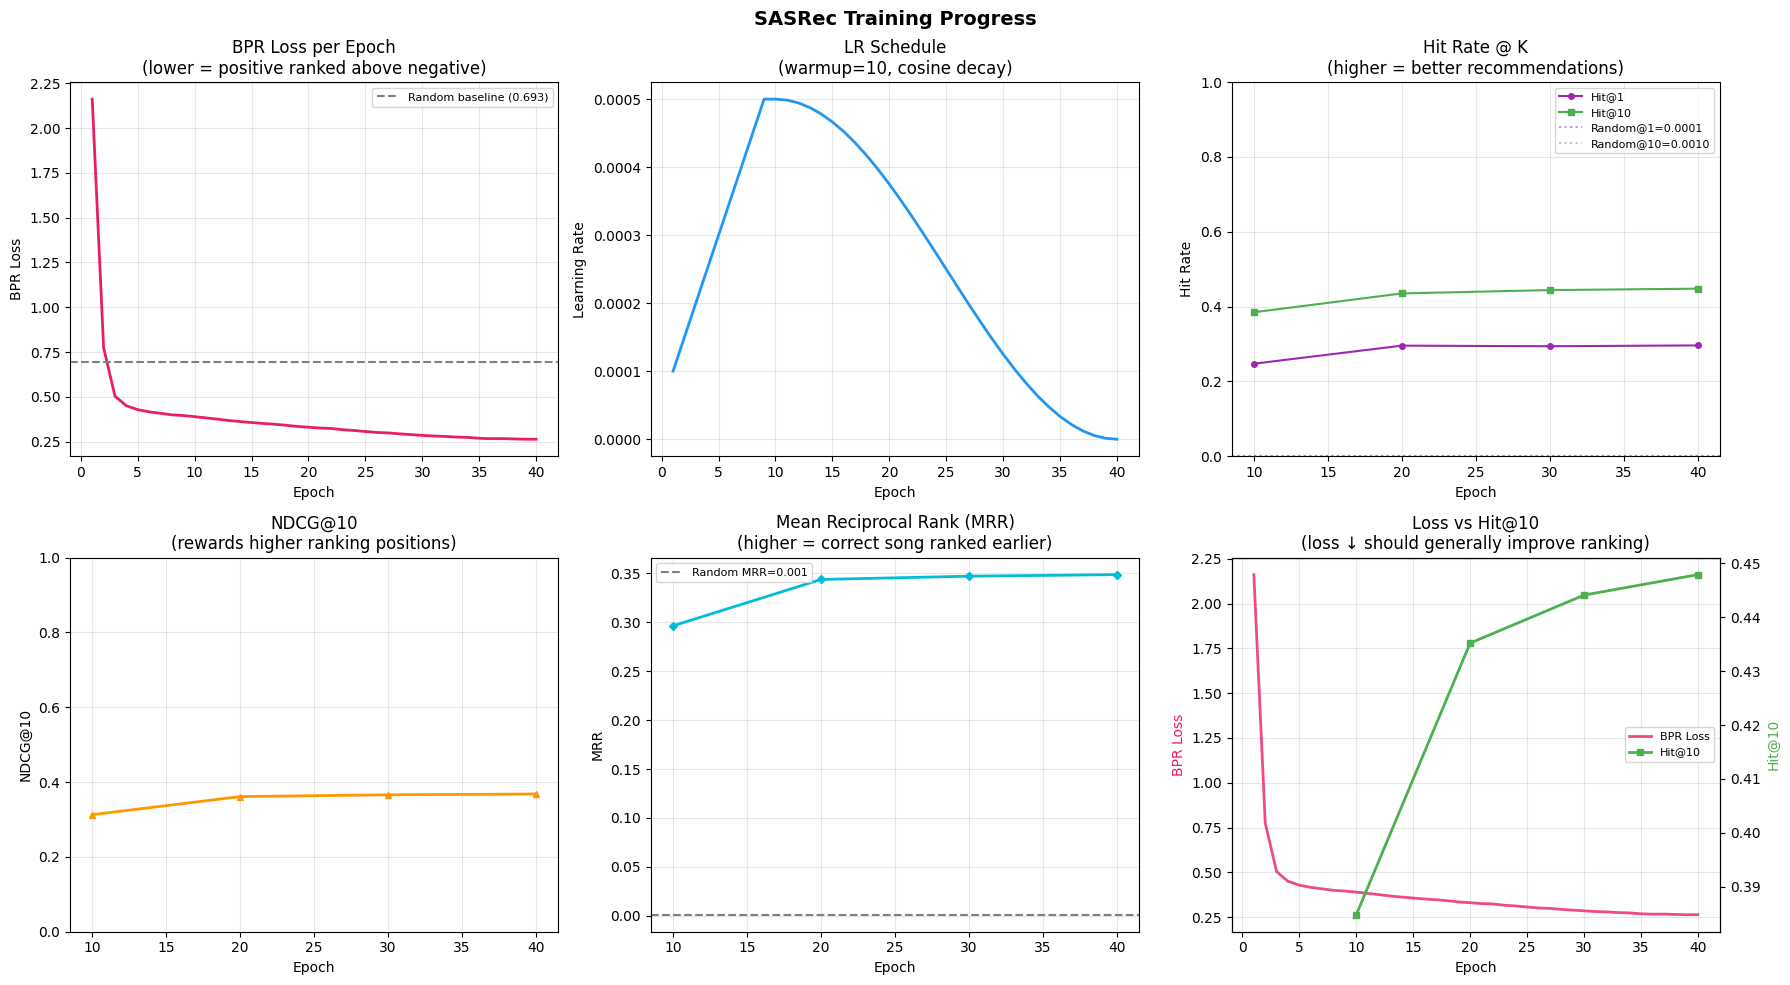

✅ Training curves saved.
Actual training epochs: 40
Best Hit@10: 0.4479


In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 8.9 — TRAINING CURVES (EARLY-STOP SAFE)
# ─────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import math

# Actual epochs completed
actual_epochs = len(train_losses)

# Evaluation epochs actually recorded
eval_epochs = list(range(
    10,
    10 * len(val_hit10_curve) + 1,
    10
))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'SASRec Training Progress',
    fontsize=14,
    fontweight='bold'
)

# ============================================================
# 1. BPR LOSS
# ============================================================
ax = axes[0, 0]

ax.plot(
    range(1, actual_epochs + 1),
    train_losses,
    color='#E91E63',
    linewidth=2
)

ax.axhline(
    math.log(2),
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label=f'Random baseline ({math.log(2):.3f})'
)

ax.set_title(
    'BPR Loss per Epoch\n'
    '(lower = positive ranked above negative)'
)
ax.set_xlabel('Epoch')
ax.set_ylabel('BPR Loss')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ============================================================
# 2. LR SCHEDULE
# ============================================================
ax = axes[0, 1]

ax.plot(
    range(1, len(lr_curve) + 1),
    lr_curve,
    color='#2196F3',
    linewidth=2
)

ax.set_title(
    f'LR Schedule\n'
    f'(warmup={WARMUP_EPOCHS}, cosine decay)'
)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.grid(True, alpha=0.3)

# ============================================================
# 3. HIT RATE
# ============================================================
ax = axes[0, 2]

ax.plot(
    eval_epochs,
    val_hit1_curve,
    marker='o',
    ms=4,
    color='#9C27B0',
    label='Hit@1'
)

ax.plot(
    eval_epochs,
    val_hit10_curve,
    marker='s',
    ms=4,
    color='#4CAF50',
    label='Hit@10'
)

ax.axhline(
    1 / N_SONGS,
    color='#9C27B0',
    linestyle=':',
    alpha=0.5,
    label=f'Random@1={1/N_SONGS:.4f}'
)

ax.axhline(
    10 / N_SONGS,
    color='#4CAF50',
    linestyle=':',
    alpha=0.5,
    label=f'Random@10={10/N_SONGS:.4f}'
)

ax.set_title(
    'Hit Rate @ K\n'
    '(higher = better recommendations)'
)

ax.set_xlabel('Epoch')
ax.set_ylabel('Hit Rate')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ============================================================
# 4. NDCG@10
# ============================================================
ax = axes[1, 0]

ax.plot(
    eval_epochs,
    val_ndcg10_curve,
    marker='^',
    ms=4,
    linewidth=2,
    color='#FF9800'
)

ax.set_title(
    'NDCG@10\n'
    '(rewards higher ranking positions)'
)

ax.set_xlabel('Epoch')
ax.set_ylabel('NDCG@10')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# ============================================================
# 5. MRR
# ============================================================
ax = axes[1, 1]

ax.plot(
    eval_epochs,
    val_mrr_curve,
    marker='D',
    ms=4,
    linewidth=2,
    color='#00BCD4'
)

random_mrr = np.mean(
    [1/r for r in range(1, N_SONGS + 1)]
)

ax.axhline(
    random_mrr,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label=f'Random MRR={random_mrr:.3f}'
)

ax.set_title(
    'Mean Reciprocal Rank (MRR)\n'
    '(higher = correct song ranked earlier)'
)

ax.set_xlabel('Epoch')
ax.set_ylabel('MRR')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ============================================================
# 6. LOSS vs HIT@10
# ============================================================
ax = axes[1, 2]
ax2 = ax.twinx()

ax.plot(
    range(1, actual_epochs + 1),
    train_losses,
    color='#E91E63',
    linewidth=2,
    alpha=0.8,
    label='BPR Loss'
)

ax2.plot(
    eval_epochs,
    val_hit10_curve,
    color='#4CAF50',
    marker='s',
    ms=4,
    linewidth=2,
    label='Hit@10'
)

ax.set_xlabel('Epoch')
ax.set_ylabel('BPR Loss', color='#E91E63')
ax2.set_ylabel('Hit@10', color='#4CAF50')

ax.set_title(
    'Loss vs Hit@10\n'
    '(loss ↓ should generally improve ranking)'
)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=8,
    loc='center right'
)

ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / 'fig_training_curves.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

print('✅ Training curves saved.')
print(f'Actual training epochs: {actual_epochs}')
print(f'Best Hit@10: {max(val_hit10_curve):.4f}')

---
## 🔧 Cell 8.10 — Attention Heatmap: What Does the Model Attend To?

This is one of the most educational cells in the notebook.  
The causal attention weights show which past songs the model focuses on  
when predicting the next song. Ideally, songs of the same genre as the  
target should receive high attention weight.

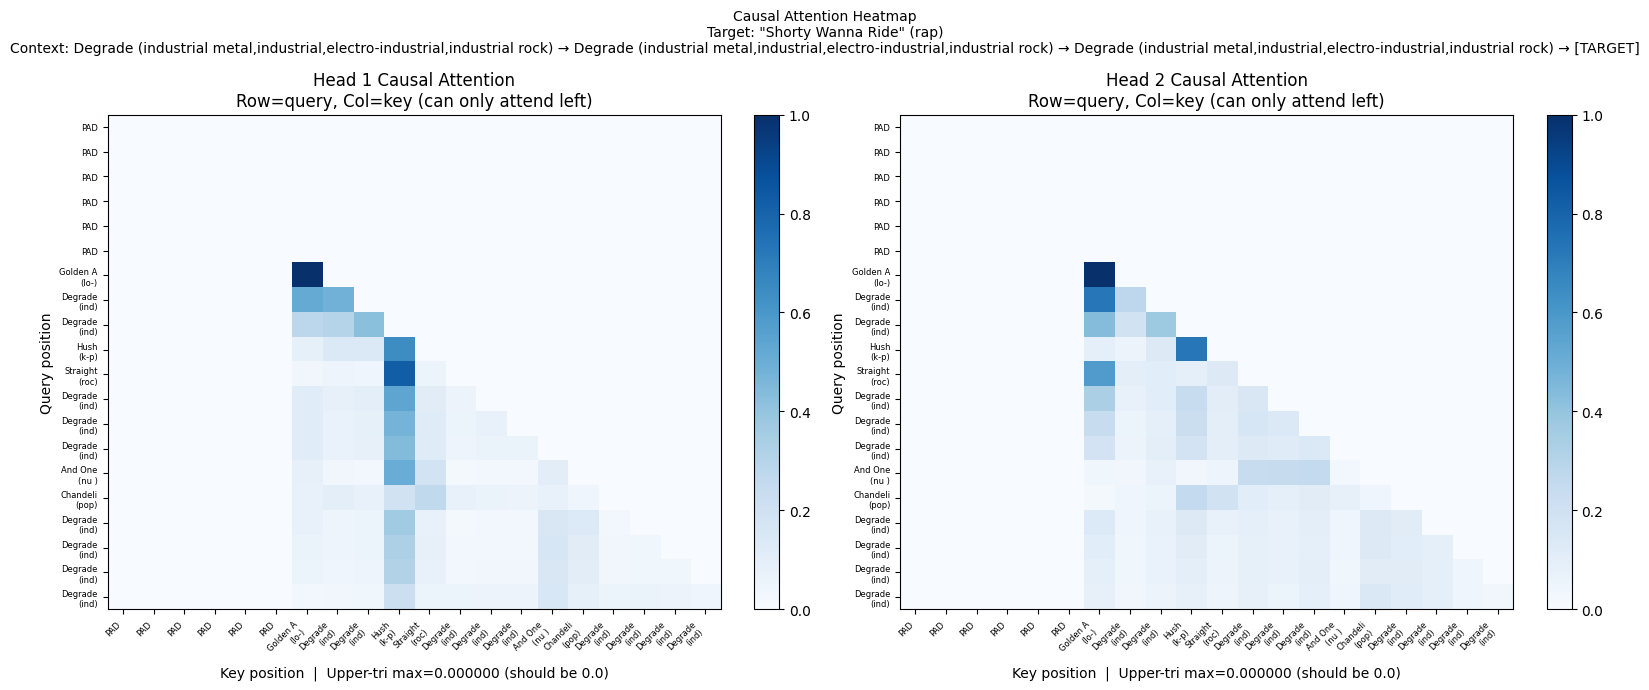

✅ Attention heatmap saved.
   Upper-triangle max attention: 0.00000000  (should be ~0.0 — causal mask verified)


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 8.10 — ATTENTION HEATMAP VISUALIZATION
# ─────────────────────────────────────────────────────────────

# Load best model
seq_model.load_state_dict(
    torch.load(MODELS_DIR / 'sasrec_best.pt', map_location=device))
seq_model.eval()

# Pick a validation sample with history length >= 5 for a readable plot
sample_ctx, sample_tgt = None, None
for ctx, tgt in validation_pairs:
    if len(ctx) >= 5:
        sample_ctx, sample_tgt = ctx, tgt
        break

if sample_ctx is None:
    sample_ctx, sample_tgt = validation_pairs[0]

# Build padded sequence
ctx_trunc = sample_ctx[-MAX_SEQ_LEN:]
T_real = len(ctx_trunc)
seq_emb_np  = np.zeros((1, MAX_SEQ_LEN, EMBED_DIM), dtype=np.float32)
seq_mask_np = np.zeros((1, MAX_SEQ_LEN), dtype=np.int64)
start = MAX_SEQ_LEN - T_real
for i, sidx in enumerate(ctx_trunc):
    seq_emb_np[0, start+i]  = song_emb_matrix[sidx]
    seq_mask_np[0, start+i] = 1

seq_emb_t  = torch.from_numpy(seq_emb_np).to(device)
seq_mask_t = torch.from_numpy(seq_mask_np).to(device)

# Forward and capture attention weights from last block
with torch.no_grad():
    user_state = seq_model(seq_emb_t, seq_mask_t)

# Extract attention from the last SASRec block's attention layer
attn_weights = seq_model.blocks[-1].attn.last_attn   # (1, heads, T, T)
if attn_weights is not None:
    attn_np = attn_weights[0].cpu().numpy()  # (heads, T, T)

    # Build x-axis labels: real positions show song title, padding shows 'PAD'
    labels = ['PAD'] * start + [
        f"{df_sub.iloc[sidx].get('title','?')[:8]}\n({df_sub.iloc[sidx].get('genre','?')[:3]})"
        for sidx in ctx_trunc
    ]

    n_heads = attn_np.shape[0]
    fig, axes = plt.subplots(1, n_heads, figsize=(8*n_heads, 7))
    if n_heads == 1:
        axes = [axes]

    for h_idx, ax in enumerate(axes):
        im = ax.imshow(attn_np[h_idx], cmap='Blues', vmin=0, vmax=1, aspect='auto')
        ax.set_title(f'Head {h_idx+1} Causal Attention\n'
                     f'Row=query, Col=key (can only attend left)')
        ax.set_xticks(range(MAX_SEQ_LEN))
        ax.set_xticklabels(labels, fontsize=6, rotation=45, ha='right')
        ax.set_yticks(range(MAX_SEQ_LEN))
        ax.set_yticklabels(labels, fontsize=6)
        ax.set_xlabel('Key position (attended to)')
        ax.set_ylabel('Query position')
        plt.colorbar(im, ax=ax, fraction=0.046)

        # Highlight: upper triangle should be exactly zero (causal constraint)
        upper_max = np.triu(attn_np[h_idx], k=1).max()
        ax.set_xlabel(f'Key position  |  Upper-tri max={upper_max:.6f} (should be 0.0)')

    # Context and target info
    target_song  = df_sub.iloc[sample_tgt]
    context_info = [f"{df_sub.iloc[s].get('title','?')[:20]} ({df_sub.iloc[s].get('genre','?')})"
                    for s in ctx_trunc]
    fig.suptitle(
        f'Causal Attention Heatmap\n'
        f'Target: "{target_song.get("title","?")[:30]}" ({target_song.get("genre","?")})\n'
        f'Context: {" → ".join(context_info[-3:])} → [TARGET]',
        fontsize=10
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig_attention_heatmap.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Attention heatmap saved.')
    print(f'   Upper-triangle max attention: {upper_max:.8f}  (should be ~0.0 — causal mask verified)')
else:
    print('⚠️  No attention weights captured — model may not have run a forward pass yet.')

**What to look for in the heatmap:**
- Upper triangle = all zeros (causal mask working correctly)
- Later positions (bottom rows) attend to more history than early positions
- High attention on same-genre songs = model learned genre preference
- `upper_max ≈ 0.0` confirms causal masking is correct

**If upper_max > 0.001:** There is a bug in the causal mask.  
Check that `torch.tril` is called correctly in `CausalMultiHeadAttention`.

---
## 🔧 Cell 8.11 — Recommendation Examples + Genre Analysis

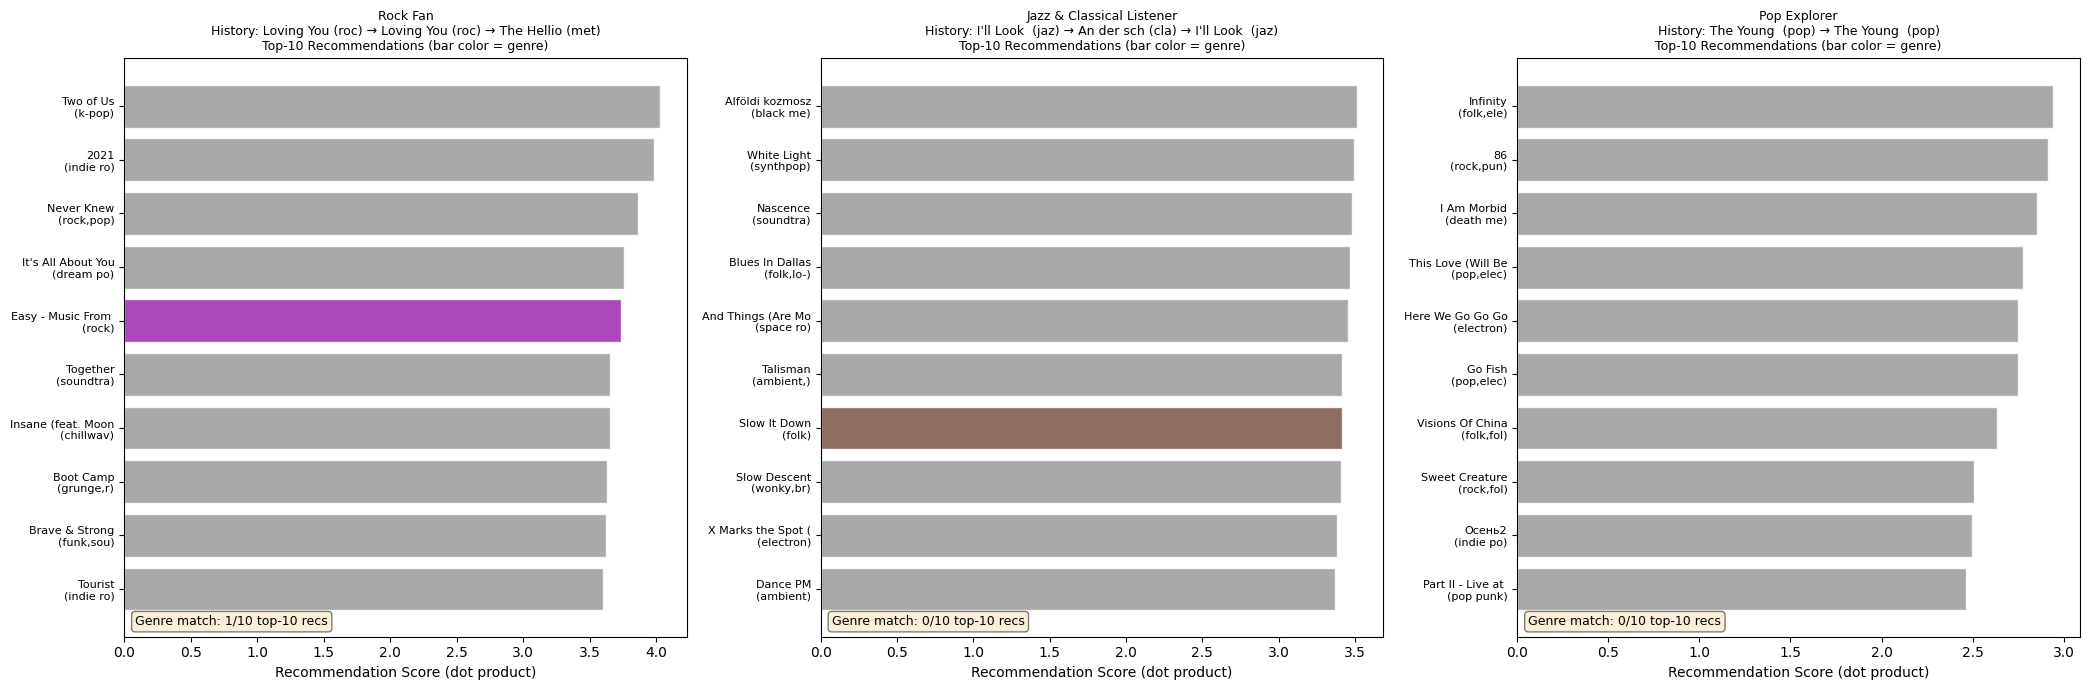

✅ Recommendation examples saved.


In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 8.11 — RECOMMENDATION EXAMPLES
# ─────────────────────────────────────────────────────────────

def recommend(history_indices, song_emb_matrix, song_emb_tensor,
              seq_model, max_seq_len, embed_dim, top_k=10, exclude=None):
    """
    Generate top-K recommendations given a listening history.

    Args:
        history_indices: list of int — song indices in listening order
        exclude        : list of int — song indices to exclude (already heard)
        top_k          : int — number of recommendations

    Returns:
        list of (song_index, score) tuples, length top_k
    """
    seq_model.eval()
    if exclude is None:
        exclude = set(history_indices)
    else:
        exclude = set(exclude) | set(history_indices)

    # Build padded sequence
    ctx   = history_indices[-max_seq_len:]
    T     = len(ctx)
    start = max_seq_len - T

    seq_emb_np  = np.zeros((1, max_seq_len, embed_dim), dtype=np.float32)
    seq_mask_np = np.zeros((1, max_seq_len), dtype=np.int64)
    for i, sidx in enumerate(ctx):
        seq_emb_np[0, start+i]  = song_emb_matrix[sidx]
        seq_mask_np[0, start+i] = 1

    seq_emb_t  = torch.from_numpy(seq_emb_np).to(device)
    seq_mask_t = torch.from_numpy(seq_mask_np).to(device)

    with torch.no_grad():
        user_state = seq_model(seq_emb_t, seq_mask_t)          # (1, 128)
        scores     = seq_model.score_all(user_state, song_emb_tensor)  # (1, 50)
        scores     = scores[0].cpu().numpy()                    # (50,)

    # Mask out excluded songs
    for idx in exclude:
        scores[idx] = -np.inf

    ranked = np.argsort(scores)[::-1][:top_k]
    return [(int(idx), float(scores[idx])) for idx in ranked]


# ── Example recommendations for 3 different user profiles ────
GENRE_COLORS = {
    'pop':'#E91E63','rock':'#9C27B0','hip-hop':'#3F51B5','hip hop':'#3F51B5',
    'electronic':'#00BCD4','classical':'#4CAF50','jazz':'#FF9800',
    'r&b':'#F44336','country':'#8BC34A','folk':'#795548','metal':'#607D8B'
}

profiles = [
    {
        'name': 'Rock Fan',
        'history_genres': ['rock', 'rock', 'metal'],
    },
    {
        'name': 'Jazz & Classical Listener',
        'history_genres': ['jazz', 'classical', 'jazz'],
    },
    {
        'name': 'Pop Explorer',
        'history_genres': ['pop', 'r&b', 'pop', 'hip-hop'],
    },
]

fig, axes = plt.subplots(1, len(profiles), figsize=(7*len(profiles), 7))
if len(profiles) == 1:
    axes = [axes]

for ax, profile in zip(axes, profiles):
    # Build history: pick first available song of each genre
    hist = []
    for g in profile['history_genres']:
        g_lower = g.lower()
        # Try exact match, then partial match
        candidates = genre_to_indices.get(g_lower, [])
        if not candidates:
            for key in genre_to_indices:
                if g_lower in key or key in g_lower:
                    candidates = genre_to_indices[key]
                    break
        if candidates:
            hist.append(candidates[0])

    if not hist:
        print(f'⚠️  Could not build history for {profile["name"]} — skipping')
        continue

    recs = recommend(hist, song_emb_matrix, SONG_EMB_TENSOR,
                     seq_model, MAX_SEQ_LEN, EMBED_DIM, top_k=10)

    # ── Plot ─────────────────────────────────────────────────
    rec_genres = [df_sub.iloc[idx].get('genre', 'unknown') for idx, _ in recs]
    rec_titles = [f"{df_sub.iloc[idx].get('title','?')[:18]}\n({df_sub.iloc[idx].get('genre','?')[:8]})"
                  for idx, _ in recs]
    rec_scores = [s for _, s in recs]
    bar_colors = [GENRE_COLORS.get(g.lower(), '#999999') for g in rec_genres]

    bars = ax.barh(range(len(recs)), rec_scores, color=bar_colors, alpha=0.85,
                   edgecolor='white')
    ax.set_yticks(range(len(recs)))
    ax.set_yticklabels(rec_titles, fontsize=8)
    ax.invert_yaxis()   # rank 1 at top
    ax.set_xlabel('Recommendation Score (dot product)')

    history_desc = ' → '.join([
        f"{df_sub.iloc[i].get('title','?')[:10]} ({df_sub.iloc[i].get('genre','?')[:3]})"
        for i in hist
    ])
    ax.set_title(f'{profile["name"]}\nHistory: {history_desc}\n'
                 f'Top-10 Recommendations (bar color = genre)',
                 fontsize=9)

    # Genre accuracy: how many recs match history genres?
    hist_genres_set = {df_sub.iloc[i].get('genre','?').lower() for i in hist}
    genre_hit = sum(1 for g in rec_genres if g.lower() in hist_genres_set)
    ax.text(0.02, 0.02, f'Genre match: {genre_hit}/{len(recs)} top-10 recs',
            transform=ax.transAxes, fontsize=9, color='black',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_recommendations.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Recommendation examples saved.')

---
## 🔧 Cell 8.12 — Embedding Space Visualization: User States vs Song Catalog

---
## 🔧 Cell 8.13 — Comprehensive Evaluation + Baseline Comparison

Running baselines...

  Method                  HIT@1      HIT@5      HIT@10     NDCG@10    MRR      
---------------------------------------------------------------------------
  Random                  0.0001     0.0004     0.0009     0.0004     0.0009   
  Popularity              0.0009     0.0035     0.0061     0.0030     0.0041   
  Content-Avg (NB7)       0.4238     0.4868     0.5071     0.4648     0.4542   
  SASRec (NB8)            0.2962     0.4062     0.4479     0.3682     0.3488     ← OUR MODEL
---------------------------------------------------------------------------
  Random@K baseline       0.0001     0.0005     0.0010     N/A        N/A      
---------------------------------------------------------------------------


C:\Users\tezpu\AppData\Local\Temp\ipykernel_29428\3540526849.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
C:\Users\tezpu\AppData\Local\Temp\ipykernel_29428\3540526849.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
C:\Users\tezpu\AppData\Local\Temp\ipykernel_29428\3540526849.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
C:\Users\tezpu\AppData\Local\Temp\ipykernel_29428\3540526849.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocat

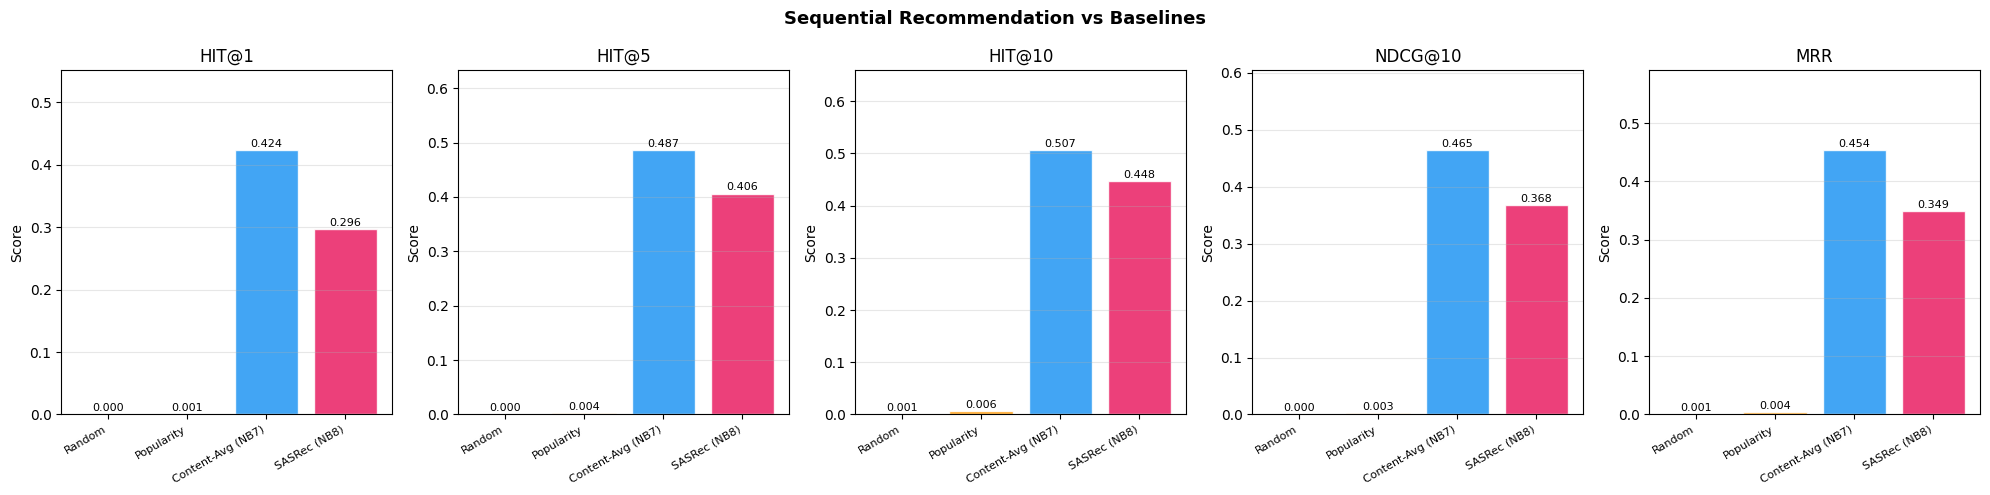

✅ Baseline comparison saved.


In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 8.13 — BASELINE COMPARISON
# ─────────────────────────────────────────────────────────────

# ── Baseline 1: Random ────────────────────────────────────────
def random_baseline(val_pairs, n_songs, top_k_list, n_trials=5):
    """Score by sampling uniformly at random."""
    results = defaultdict(list)
    rng = np.random.default_rng(0)
    for ctx, tgt in val_pairs:
        scores = rng.uniform(0, 1, n_songs)
        ranked = np.argsort(scores)[::-1]
        rank   = int(np.where(ranked == tgt)[0][0]) + 1
        results['mrr'].append(1.0 / rank)
        for k in top_k_list:
            results[f'hit@{k}'].append(1.0 if rank <= k else 0.0)
            results[f'ndcg@{k}'].append((1.0/math.log2(rank+1)) if rank <= k else 0.0)
    return {k: float(np.mean(v)) for k, v in results.items()}


# ── Baseline 2: Popularity ────────────────────────────────────
def popularity_baseline(val_pairs, simulated_histories, n_songs, top_k_list):
    """Score by global play count — most listened = highest score."""
    play_counts = np.zeros(n_songs)
    for u in simulated_histories:
        for sidx in u['history']:
            play_counts[sidx] += 1
    results = defaultdict(list)
    for ctx, tgt in val_pairs:
        scores = play_counts.copy()
        ranked = np.argsort(scores)[::-1]
        rank   = int(np.where(ranked == tgt)[0][0]) + 1
        results['mrr'].append(1.0 / rank)
        for k in top_k_list:
            results[f'hit@{k}'].append(1.0 if rank <= k else 0.0)
            results[f'ndcg@{k}'].append((1.0/math.log2(rank+1)) if rank <= k else 0.0)
    return {k: float(np.mean(v)) for k, v in results.items()}


# ── Baseline 3: Content similarity (NB7 embeddings, no sequential modeling) ──
def content_similarity_baseline(val_pairs, song_emb_matrix, top_k_list):
    """
    For each context, average the song embeddings in history,
    then score all songs by cosine similarity to that average.
    This represents content-based filtering WITHOUT sequential modeling.
    """
    norms = np.linalg.norm(song_emb_matrix, axis=1, keepdims=True) + 1e-8
    normed = song_emb_matrix / norms
    results = defaultdict(list)
    for ctx, tgt in val_pairs:
        ctx_embs = song_emb_matrix[ctx]        # (T, 128)
        avg_emb  = ctx_embs.mean(axis=0)       # (128,)
        avg_norm = np.linalg.norm(avg_emb) + 1e-8
        avg_unit = avg_emb / avg_norm
        scores   = normed @ avg_unit           # (50,)  cosine similarity
        ranked   = np.argsort(scores)[::-1]
        rank     = int(np.where(ranked == tgt)[0][0]) + 1
        results['mrr'].append(1.0 / rank)
        for k in top_k_list:
            results[f'hit@{k}'].append(1.0 if rank <= k else 0.0)
            results[f'ndcg@{k}'].append((1.0/math.log2(rank+1)) if rank <= k else 0.0)
    return {k: float(np.mean(v)) for k, v in results.items()}


# ── Run all baselines ─────────────────────────────────────────
print('Running baselines...')
rand_metrics     = random_baseline(validation_pairs, N_SONGS, TOP_K)
pop_metrics      = popularity_baseline(validation_pairs, simulated_histories, N_SONGS, TOP_K)
content_metrics  = content_similarity_baseline(validation_pairs, song_emb_matrix, TOP_K)
sasrec_metrics   = evaluate(seq_model, val_loader, SONG_EMB_TENSOR, TOP_K)

# ── Results table ─────────────────────────────────────────────
methods = {
    'Random':           rand_metrics,
    'Popularity':       pop_metrics,
    'Content-Avg (NB7)':content_metrics,
    'SASRec (NB8)':     sasrec_metrics,
}

metric_keys = ['hit@1', 'hit@5', 'hit@10', 'ndcg@10', 'mrr']

print(f'\n{"="*75}')
print(f'  {"Method":<22}  ' + '  '.join(f'{m.upper():<9}' for m in metric_keys))
print(f'{"-"*75}')
for method, metrics in methods.items():
    vals = [metrics.get(m, 0.0) for m in metric_keys]
    flag = '  ← OUR MODEL' if 'SASRec' in method else ''
    print(f'  {method:<22}  ' + '  '.join(f'{v:<9.4f}' for v in vals) + flag)
print(f'{"-"*75}')
print(f'  {"Random@K baseline":<22}  '
      + '  '.join(f'{v:<9}' for v in [f'{1/N_SONGS:.4f}', f'{5/N_SONGS:.4f}',
                                        f'{10/N_SONGS:.4f}', 'N/A', 'N/A']))
print(f'{"-"*75}')

# ── Bar chart comparison ──────────────────────────────────────
plot_metrics = ['hit@1', 'hit@5', 'hit@10', 'ndcg@10', 'mrr']
method_names = list(methods.keys())
bar_colors   = ['#9E9E9E', '#FF9800', '#2196F3', '#E91E63']

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4*len(plot_metrics), 5))
fig.suptitle('Sequential Recommendation vs Baselines', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, plot_metrics):
    vals  = [methods[m].get(metric, 0.0) for m in method_names]
    bars  = ax.bar(method_names, vals, color=bar_colors, alpha=0.85, edgecolor='white')
    ax.set_title(metric.upper())
    ax.set_ylim(0, max(max(vals) * 1.3, 0.05))
    ax.set_ylabel('Score')
    ax.set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_baseline_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Baseline comparison saved.')

---
## 🔧 Cell 8.14 — Debugging Checks

Run these diagnostics if results are unexpectedly bad.

In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 8.14 — DEBUGGING + SANITY CHECKS
# ─────────────────────────────────────────────────────────────

print('=' * 60)
print('SASRec DEBUGGING CHECKS')
print('=' * 60)

# ── Check 1: NaN in model outputs ────────────────────────────
print('\n1. NaN / Inf check in model outputs:')
seq_model.eval()
batch = next(iter(val_loader))
with torch.no_grad():
    us = seq_model(batch['seq_emb'].to(device), batch['seq_mask'].to(device))
    sc = seq_model.score_all(us, SONG_EMB_TENSOR)

for name, tensor in [('user_state', us), ('scores', sc)]:
    has_nan = torch.any(torch.isnan(tensor)).item()
    has_inf = torch.any(torch.isinf(tensor)).item()
    status  = '✅' if not has_nan and not has_inf else '❌'
    print(f'   {name:<14}: NaN={has_nan}  Inf={has_inf}  {status}')

# ── Check 2: Score distribution ──────────────────────────────
print('\n2. Score distribution (should have variance — not all equal):')
sc_np = sc.cpu().numpy()
print(f'   Mean: {sc_np.mean():.4f}  Std: {sc_np.std():.4f}  '
      f'Min: {sc_np.min():.4f}  Max: {sc_np.max():.4f}')
if sc_np.std() < 0.01:
    print('   ⚠️  COLLAPSED: all songs get nearly identical scores')
    print('      → Increase LR, reduce weight decay, or retrain NB7 encoder')
else:
    print('   ✅ Scores have sufficient variance')

# ── Check 3: Causal mask correctness ─────────────────────────
print('\n3. Causal mask check (upper triangle must be 0):')
# Trigger a forward pass to populate last_attn
with torch.no_grad():
    _ = seq_model(batch['seq_emb'].to(device), batch['seq_mask'].to(device))
last_block_attn = seq_model.blocks[-1].attn.last_attn  # (B, heads, T, T)
if last_block_attn is not None:
    attn_np = last_block_attn.cpu().numpy()
    T = attn_np.shape[-1]
    upper_vals = []
    for b in range(attn_np.shape[0]):
        for h in range(attn_np.shape[1]):
            upper_vals.append(np.triu(attn_np[b, h], k=1).max())
    max_upper = max(upper_vals)
    print(f'   Max attention weight in upper triangle: {max_upper:.8f}')
    if max_upper > 1e-5:
        print(f'   ⚠️  CAUSAL MASK FAILED — future positions attended to!')
    else:
        print(f'   ✅ Causal mask correct — no future leakage')
else:
    print('   ⚠️  Could not access attention weights')

# ── Check 4: ResNet coverage ──────────────────────────────────
print('\n4. ResNet TSV coverage for subset songs:')
n_found   = sum(1 for sid in song_ids if sid in resnet_row)
n_missing = N_SONGS - n_found
print(f'   Found  : {n_found}/{N_SONGS}')
print(f'   Missing: {n_missing}/{N_SONGS}')
if n_missing > 0:
    missing_ids = [sid for sid in song_ids if sid not in resnet_row]
    print(f'   Missing IDs: {missing_ids[:5]} ...')
    print('   → Check dtype={0: str} in pd.read_csv for the TSV')
    print('   → Check that TSV first column format matches subset CSV id format')
if n_missing == N_SONGS:
    print('   ❌ ALL MISSING — image modality disabled. Results will be sub-optimal.')
elif n_missing == 0:
    print('   ✅ All songs have ResNet embeddings')

# ── Check 5: Left-padding correctness ────────────────────────
print('\n5. Left-padding correctness:')
batch2 = next(iter(train_loader))
masks2 = batch2['seq_mask']   # (B, T)
for b_idx in range(min(3, BATCH_SIZE)):
    m = masks2[b_idx].tolist()
    # Find transition point from 0→1
    first_one = next((i for i, v in enumerate(m) if v == 1), MAX_SEQ_LEN)
    all_zeros_before = all(v == 0 for v in m[:first_one])
    all_ones_after   = all(v == 1 for v in m[first_one:])
    status = '✅' if all_zeros_before and all_ones_after else '❌'
    print(f'   Sample {b_idx}: real_len={sum(m)}  first_real_pos={first_one}  {status}')

print(f'\n{'=' * 60}')
print('All debugging checks complete.')

SASRec DEBUGGING CHECKS

1. NaN / Inf check in model outputs:
   user_state    : NaN=False  Inf=False  ✅
   scores        : NaN=False  Inf=False  ✅

2. Score distribution (should have variance — not all equal):
   Mean: 0.2773  Std: 1.6156  Min: -9.3719  Max: 10.4112
   ✅ Scores have sufficient variance

3. Causal mask check (upper triangle must be 0):
   Max attention weight in upper triangle: 0.00000000
   ✅ Causal mask correct — no future leakage

4. ResNet TSV coverage for subset songs:
   Found  : 9023/10000
   Missing: 977/10000
   Missing IDs: ['P9zu2KbE0a5rlbpF', 'Rmci2Ia3zFavQU0m', '95YYULAxiUx9CTBl', 'x5aH4JW1WY40zgfM', 'Bslsq4YxQsat3FBf'] ...
   → Check dtype={0: str} in pd.read_csv for the TSV
   → Check that TSV first column format matches subset CSV id format

5. Left-padding correctness:
   Sample 0: real_len=15  first_real_pos=5  ✅
   Sample 1: real_len=1  first_real_pos=19  ✅
   Sample 2: real_len=5  first_real_pos=15  ✅

All debugging checks complete.


---
## 🔧 Cell 8.15 — Save Everything for Notebook 9

In [21]:
# ─────────────────────────────────────────────────────────────
# CELL 8.15 — SAVE OUTPUTS FOR NOTEBOOK 9
# ─────────────────────────────────────────────────────────────

PROC_DIR = BASE_DIR / 'data' / 'processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)

# ── Save user histories and val pairs ────────────────────────
import json
histories_save = [
    {'user_id': u['user_id'],
     'pref_genres': u['pref_genres'],
     'history': u['history']}
    for u in simulated_histories
]
with open(PROC_DIR / 'simulated_histories.json', 'w') as f:
    json.dump(histories_save, f)
print(f'✅ Saved simulated_histories.json ({len(histories_save)} users)')

# ── Save all validation pairs ────────────────────────────────
val_save = [{'context': list(ctx), 'target': int(tgt)}
            for ctx, tgt in validation_pairs]
with open(PROC_DIR / 'validation_pairs.json', 'w') as f:
    json.dump(val_save, f)
print(f'✅ Saved validation_pairs.json ({len(val_save)} pairs)')

# ── Save user state embeddings for all simulated users ────────
np.save(PROC_DIR / 'user_states.npy', user_states_np)
print(f'✅ Saved user_states.npy  {user_states_np.shape}')

# ── Save final metrics ────────────────────────────────────────
final_metrics = evaluate(seq_model, val_loader, SONG_EMB_TENSOR, TOP_K)
metrics_save  = {
    'sasrec':   final_metrics,
    'random':   rand_metrics,
    'popularity': pop_metrics,
    'content':  content_metrics,
    'n_songs':  N_SONGS,
    'n_users':  N_USERS,
    'best_epoch': best_epoch,
    'best_hit10': best_hit10,
}
with open(PROC_DIR / 'nb8_metrics.json', 'w') as f:
    json.dump(metrics_save, f, indent=2)
print(f'✅ Saved nb8_metrics.json')

# ── Summary ───────────────────────────────────────────────────
print(f'\n{"="*55}')
print('NB8 OUTPUTS SAVED')
print(f'{"="*55}')
print(f'  models/sasrec_best.pt          ← best checkpoint by Hit@10')
print(f'  models/sasrec_final.pt         ← final epoch checkpoint')
print(f'  processed/simulated_histories.json')
print(f'  processed/validation_pairs.json')
print(f'  processed/user_states.npy      {user_states_np.shape}')
print(f'  processed/nb8_metrics.json')
print(f'  figures/sequential/')
print(f'    fig_training_curves.png')
print(f'    fig_attention_heatmap.png')
print(f'    fig_recommendations.png')
print(f'    fig_user_song_pca.png')
print(f'    fig_baseline_comparison.png')
print(f'\nFinal SASRec metrics:')
for k, v in sorted(final_metrics.items()):
    print(f'  {k:<12}: {v:.4f}')

✅ Saved simulated_histories.json (10000 users)
✅ Saved validation_pairs.json (10000 pairs)
✅ Saved user_states.npy  (10000, 128)
✅ Saved nb8_metrics.json

NB8 OUTPUTS SAVED
  models/sasrec_best.pt          ← best checkpoint by Hit@10
  models/sasrec_final.pt         ← final epoch checkpoint
  processed/simulated_histories.json
  processed/validation_pairs.json
  processed/user_states.npy      (10000, 128)
  processed/nb8_metrics.json
  figures/sequential/
    fig_training_curves.png
    fig_attention_heatmap.png
    fig_recommendations.png
    fig_user_song_pca.png
    fig_baseline_comparison.png

Final SASRec metrics:
  hit@1       : 0.2962
  hit@10      : 0.4479
  hit@5       : 0.4062
  mrr         : 0.3488
  ndcg@1      : 0.2962
  ndcg@10     : 0.3682
  ndcg@5      : 0.3547


---
## ✅ Notebook 8 Complete

### What Was Built

| Component | Description | Output Shape |
|-----------|-------------|-------------|
| `VisualProjector` | ResNet-4096 → 128 (reused from NB5/6) | (B, 128) |
| `MultimodalSongEncoder` | Frozen NB7 encoder — audio+lyrics+resnet | (B, 128) |
| `SequentialRecommendationDataset` | Left-padded sequence tensors + neg sampling | (B,20,128) |
| `CausalMultiHeadAttention` | MHA with causal + padding mask | (B,T,128) |
| `SASRecBlock` | Pre-norm causal transformer block | (B,T,128) |
| `SASRec` | Full sequential recommender | (B,128) user state |
| `bpr_loss` | Bayesian Personalized Ranking | scalar |
| `evaluate` | Hit@K, NDCG@K, MRR on validation set | dict |
| Baseline comparison | Random, Popularity, Content-Avg | table + plot |

### Image Modality Architecture

```
id_resnet.tsv  →  pd.read_csv(..., dtype={0:str})  →  resnet_row dict
                                                              ↓
                             for each song: resnet_row[song_id]  →  (4096,) numpy
                                                              ↓
                                              VisualProjector MLP
                                        Linear(4096→512) → GELU → Linear(512→128)
                                                              ↓
                                                        (128,) image embedding
```

### Key Design Decisions

- **Encoder frozen** — NB7 embeddings are fixed inputs; only SASRec weights train
- **Left-padding** — ensures last real position = most recent song = model output
- **Learnable positional embeddings** — order in listening history has semantic meaning
- **Causal mask** — prevents future leakage; verified by upper-triangle check
- **BPR loss** — appropriate for implicit feedback; more realistic than cross-entropy
- **dtype={0: str}** — critical for ResNet TSV zero-padded ID matching

### Next: Notebook 9 — Cold Start Evaluation
Evaluate USER cold start (0/1/3/5 seed songs) and ITEM cold start  
(held-out songs with zero interactions) using the trained SASRec + multimodal encoder.